# Exploratory Data Analysis

## load

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import combinations
from collections import Counter, defaultdict
import warnings
import networkx as nx

In [2]:
df_posting: pd.DataFrame = pd.read_csv("https://drive.usercontent.google.com/download?id=1vM5fVPrZVtBruD7LLZVVeHVAApqQgHCt&export=download&authuser=0&confirm=t&uuid=802d5b6c-b596-4398-a3c1-caf0be5f834f&at=ALBwUgklTDT44mmgIpzoju6Uky2r%3A1778995998426")
df_skills: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1ftdeNOEpnm4a-mR6jI53K6u_d__ov2XB")
df_salaries: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1mtwW1JImMOLuWrm4nx4CLb_ZOlo4vAQr")
df_job_skills: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=14O385R-O1d3P1zqSKFkHotdLRuW39DT8")
df_job_industries: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1tJgLzRYT5jEZaS_Idxa3OpJso6gVybtr")
df_industries: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1F_jJyBI0IMvXN2yZ5GeNaQHMgi2GJJtZ")
df_employee_counts: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1yMKvKqgpSLO2fyddrAjliOospckkEUsl")
df_company_specialities: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1JYg9xauTVR6hf4uHJPklxqtiqdPhNC21")
df_company_industries: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1EeVRluUpy0-UyxFbrLptMYroZK8YM5_i")
df_companies: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=1nTnBwtOibA3f9areJNXMPK7TH_lJ5i2P")
df_benefits: pd.DataFrame = pd.read_csv("https://drive.google.com/uc?export=download&id=17qOKff9mORXwLAKrLGVBTDsxl_YgqskU")

## assesing cleaning

In [3]:
df_posting.head()
df_posting.describe()
df_posting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_posting_id              123849 non-null  int64  
 1   title                       123849 non-null  object 
 2   job_description             123842 non-null  object 
 3   location                    123849 non-null  object 
 4   company_id                  122132 non-null  float64
 5   views                       122160 non-null  float64
 6   formatted_work_type         123849 non-null  object 
 7   applies                     123849 non-null  float64
 8   original_listed_time        123849 non-null  float64
 9   remote_allowed              123849 non-null  float64
 10  job_posting_url             123849 non-null  object 
 11  application_url             87184 non-null   object 
 12  application_type            123849 non-null  object 
 13  expiry        

In [4]:
df_skills.head()
df_skills.describe()
df_skills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   skill_id    35 non-null     object
 1   skill_name  35 non-null     object
dtypes: object(2)
memory usage: 692.0+ bytes


In [5]:
df_salaries.head()
df_salaries.describe()
df_salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40785 entries, 0 to 40784
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   salary_id          40785 non-null  int64  
 1   job_posting_id     40785 non-null  int64  
 2   max_salary         33947 non-null  float64
 3   med_salary         6838 non-null   float64
 4   min_salary         33947 non-null  float64
 5   pay_period         40785 non-null  object 
 6   currency           40785 non-null  object 
 7   compensation_type  40785 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 2.5+ MB


In [6]:
df_job_skills.head()
df_job_skills.describe()
df_job_skills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213768 entries, 0 to 213767
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   job_posting_id  213768 non-null  int64 
 1   skill_id        213768 non-null  object
 2   job_skill_id    213768 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.9+ MB


In [7]:
df_job_industries.head()
df_job_industries.describe()
df_job_industries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164808 entries, 0 to 164807
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   job_posting_id     164808 non-null  int64
 1   industry_id        164808 non-null  int64
 2   job_industries_id  164808 non-null  int64
dtypes: int64(3)
memory usage: 3.8 MB


In [8]:
df_industries.head()
df_industries.describe()
df_industries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   industry_id    422 non-null    int64 
 1   industry_name  388 non-null    object
dtypes: int64(1), object(1)
memory usage: 6.7+ KB


In [9]:
df_employee_counts.head()
df_employee_counts.describe()
df_employee_counts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35787 entries, 0 to 35786
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   company_id          35787 non-null  int64
 1   employee_count      35787 non-null  int64
 2   follower_count      35787 non-null  int64
 3   time_recorded       35787 non-null  int64
 4   employee_counts_id  35787 non-null  int64
dtypes: int64(5)
memory usage: 1.4 MB


In [10]:
df_company_specialities.head()
df_company_specialities.describe()
df_company_specialities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169387 entries, 0 to 169386
Data columns (total 3 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   company_id               169387 non-null  int64 
 1   speciality               169387 non-null  object
 2   company_specialities_id  169387 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.9+ MB


In [11]:
df_company_industries.head()
df_company_industries.describe()
df_company_industries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24375 entries, 0 to 24374
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_id             24375 non-null  int64  
 1   industry_id            24374 non-null  float64
 2   company_industries_id  24375 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 571.4 KB


In [12]:
df_companies.head()
df_companies.describe()
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24473 entries, 0 to 24472
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_id             24473 non-null  int64  
 1   company_name           24472 non-null  object 
 2   companies_description  24176 non-null  object 
 3   company_size           21699 non-null  float64
 4   state                  24451 non-null  object 
 5   country                24473 non-null  object 
 6   city                   24472 non-null  object 
 7   zip_code               24445 non-null  object 
 8   address                24451 non-null  object 
 9   url                    24473 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.9+ MB


In [13]:
df_benefits.head()
df_benefits.describe()
df_benefits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67943 entries, 0 to 67942
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_posting_id  67943 non-null  int64 
 1   inferred        67943 non-null  int64 
 2   type            67943 non-null  object
 3   benefits_id     67943 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.1+ MB


In [14]:
# ==========================================
# 2. Cleaning df_posting
# ==========================================
# Konversi kolom waktu ke datetime. Format asli adalah timestamp dalam milliseconds (float64).
time_cols_posting = ['original_listed_time', 'expiry', 'closed_time', 'listed_time']
for col in time_cols_posting:
    df_posting[col] = pd.to_datetime(df_posting[col], unit='ms', errors='coerce')

# Mengubah tipe data 'company_id' dari float64 ke Int64 (nullable integer) agar presisi ID terjaga meski ada nilai NaN.
df_posting['company_id'] = df_posting['company_id'].astype('Int64')

# Mengisi missing values pada kolom teks dengan 'Unknown' atau string kosong.
text_cols_posting = ['job_description', 'formatted_experience_level', 'skills_desc', 'posting_domain', 'application_url']
for col in text_cols_posting:
    df_posting[col] = df_posting[col].fillna('Unknown')

# Mengubah remote_allowed menjadi boolean/int.
df_posting['remote_allowed'] = df_posting['remote_allowed'].fillna(0).astype('Int64')

# ==========================================
# 3. Cleaning df_salaries
# ==========================================
# Membuat kolom estimasi gaji ('med_salary_est') karena 'med_salary' memiliki banyak missing values.
# Jika 'med_salary' kosong, kita ambil rata-rata dari 'min_salary' dan 'max_salary'.
df_salaries['med_salary_est'] = df_salaries['med_salary'].fillna((df_salaries['min_salary'] + df_salaries['max_salary']) / 2)

# ==========================================
# 4. Cleaning df_industries & df_company_industries
# ==========================================
# Fill missing value pada nama industri.
df_industries['industry_name'] = df_industries['industry_name'].fillna('Unknown')

# Drop 1 baris nilai null pada 'industry_id' di tabel company_industries, lalu konversi ke integer.
df_company_industries = df_company_industries.dropna(subset=['industry_id'])
df_company_industries['industry_id'] = df_company_industries['industry_id'].astype('Int64')

# ==========================================
# 5. Cleaning df_employee_counts
# ==========================================
# Konversi time_recorded ke datetime (asumsi timestamp dalam satuan seconds).
df_employee_counts['time_recorded'] = pd.to_datetime(df_employee_counts['time_recorded'], unit='s', errors='coerce')

# ==========================================
# 6. Cleaning df_companies
# ==========================================
# Mengisi missing values pada kolom teks informatif.
text_cols_companies = ['company_name', 'companies_description', 'state', 'city', 'zip_code', 'address']
for col in text_cols_companies:
    df_companies[col] = df_companies[col].fillna('Unknown')

# Konversi company_size ke tipe Int64.
df_companies['company_size'] = df_companies['company_size'].astype('Int64')

## Pertanyaan Bisnis
1. Apa saja skill yang paling banyak diminta per industri, level pengalaman, dan tipe pekerjaan, serta bagaimana korelasinya dengan rentang gaji ?
2. Bagaimana pola rasio aplikasi terhadap views (apply-through-rate) berdasarkan kompleksitas skill, lokasi, dan kebijakan remote ?
3. Skill apa yang sering muncul bersamaan (co-occurrence) dalam satu lowongan, dan kombinasi mana yang paling prediktif terhadap gaji tinggi atau penutupan lowongan yang cepat ?
4. Bagaimana variasi kompensasi (gaji) dipengaruhi oleh kombinasi: industri, skill teknis vs. non-teknis, ukuran perusahaan, dan lokasi ?

### EDA(1): Apa saja skill yang paling banyak diminta per industri, level pengalaman, dan tipe pekerjaan, serta bagaimana korelasinya dengan rentang gaji ?

#### exploratory

In [15]:
# Menggabungkan df_posting dengan df_job_skills untuk menghubungkan pekerjaan dengan skill
df_eda = df_posting.merge(df_job_skills, on='job_posting_id', how='left') # [cite: 6, 7, 72]

# Menambahkan nama skill dari df_skills
df_eda = df_eda.merge(df_skills, on='skill_id', how='left') # [cite: 49, 73]

# Menggabungkan dengan df_job_industries dan df_industries untuk mendapatkan nama industri
df_eda = df_eda.merge(df_job_industries, on='job_posting_id', how='left') # [cite: 81]
df_eda = df_eda.merge(df_industries, on='industry_id', how='left') # [cite: 83, 88]

# Menggabungkan dengan data gaji untuk melihat korelasi
df_eda = df_eda.merge(df_salaries[['job_posting_id', 'min_salary', 'max_salary', 'med_salary_est']],
                      on='job_posting_id', how='left') # [cite: 58, 162, 163]

# Drop baris yang tidak memiliki informasi skill untuk fokus pada pertanyaan
df_eda_skills = df_eda.dropna(subset=['skill_name'])

In [16]:
# Menghitung skill terpopuler per industri
top_skills_industry = df_eda_skills.groupby(['industry_name', 'skill_name']).size().reset_index(name='count')
top_skills_industry = top_skills_industry.sort_values(['industry_name', 'count'], ascending=[True, False])

# Menampilkan top 3 skill untuk tiap industri
top_3_per_industry = top_skills_industry.groupby('industry_name').head(3)
print("Top 3 Skills per Industri:")
print(top_3_per_industry.head(15)) # Tampilkan sebagian sampel

Top 3 Skills per Industri:
                                       industry_name              skill_name  \
0   Abrasives and Nonmetallic Minerals Manufacturing             Engineering   
2                 Accessible Architecture and Design                  Design   
3                 Accessible Architecture and Design             Engineering   
5                 Accessible Architecture and Design      Project Management   
11                   Accommodation and Food Services        Customer Service   
8                    Accommodation and Food Services          Administrative   
9                    Accommodation and Food Services                 Analyst   
19                                        Accounting     Accounting/Auditing   
30                                        Accounting                 Finance   
34                                        Accounting  Information Technology   
57                         Administration of Justice                   Legal   
52           

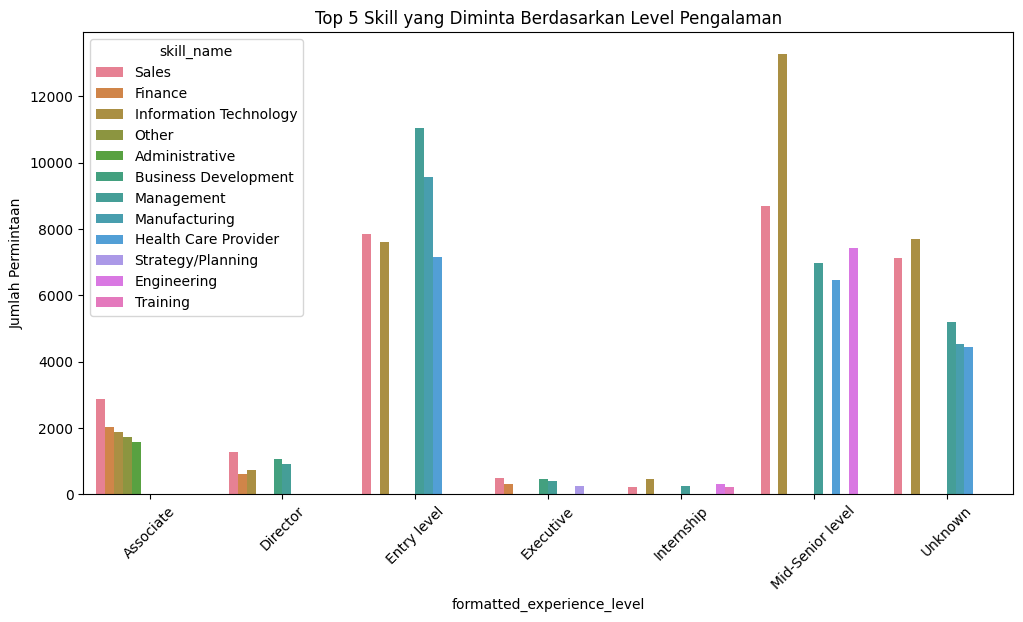

In [17]:
# Menghitung skill terpopuler per level pengalaman
top_skills_exp = df_eda_skills.groupby(['formatted_experience_level', 'skill_name']).size().reset_index(name='count')
top_skills_exp = top_skills_exp.sort_values(['formatted_experience_level', 'count'], ascending=[True, False])

# Visualisasi Top 5 Skills per Level Pengalaman
top_5_exp = top_skills_exp.groupby('formatted_experience_level').head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_5_exp, x='formatted_experience_level', y='count', hue='skill_name')
plt.title('Top 5 Skill yang Diminta Berdasarkan Level Pengalaman')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Permintaan')
plt.show()

In [18]:
# Menghitung skill terpopuler per tipe pekerjaan
top_skills_worktype = df_eda_skills.groupby(['formatted_work_type', 'skill_name']).size().reset_index(name='count')
top_skills_worktype = top_skills_worktype.sort_values(['formatted_work_type', 'count'], ascending=[True, False])

print("Top Skills berdasarkan Tipe Pekerjaan:")
print(top_skills_worktype.groupby('formatted_work_type').head(3))

Top Skills berdasarkan Tipe Pekerjaan:
    formatted_work_type              skill_name  count
16             Contract  Information Technology   6368
11             Contract             Engineering   3223
14             Contract    Health Care Provider   1961
51            Full-time  Information Technology  24129
64            Full-time                   Sales  23603
53            Full-time              Management  22608
85           Internship  Information Technology    296
98           Internship                   Sales    201
80           Internship             Engineering    185
116               Other    Health Care Provider    184
131               Other                   Sales    164
108               Other    Business Development    138
165           Part-time                   Sales   3439
150           Part-time    Health Care Provider   2360
141           Part-time    Business Development   2093
200           Temporary                   Sales    353
176           Temporary   

Korelasi Pearson antara Jumlah Permintaan Skill dan Median Gaji: -0.2076


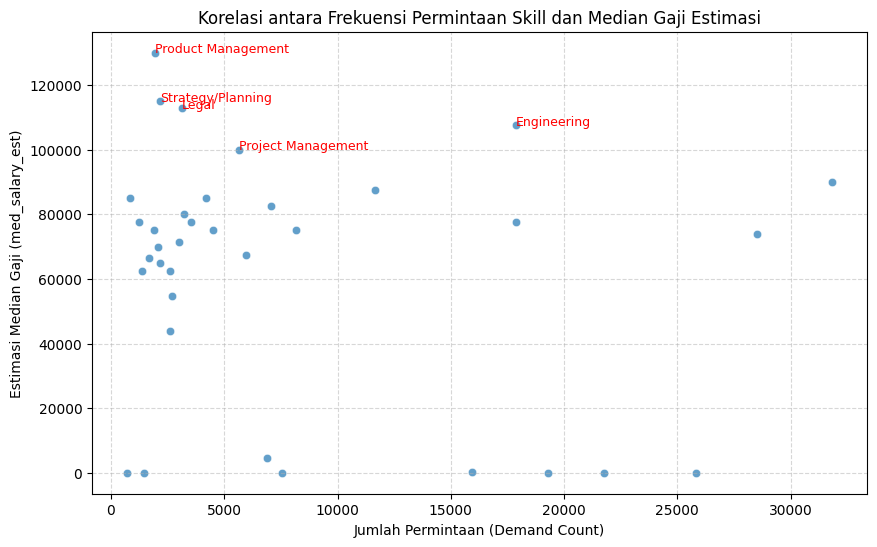

In [19]:
# Agregasi data pada level skill
skill_salary_analysis = df_eda_skills.groupby('skill_name').agg(
    demand_count=('skill_name', 'count'), # Seberapa banyak skill ini diminta
    avg_med_salary=('med_salary_est', 'median'), # Nilai tengah dari estimasi gaji
    min_salary_avg=('min_salary', 'mean'), # Rata-rata gaji minimal (opsional)
    max_salary_avg=('max_salary', 'mean')  # Rata-rata gaji maksimal (opsional)
).reset_index()

# Hapus missing values pada estimasi gaji sebelum menghitung korelasi
skill_salary_analysis = skill_salary_analysis.dropna(subset=['avg_med_salary'])

# Menghitung korelasi antara permintaan (demand_count) dan rentang gaji (avg_med_salary)
correlation = skill_salary_analysis['demand_count'].corr(skill_salary_analysis['avg_med_salary'])
print(f"Korelasi Pearson antara Jumlah Permintaan Skill dan Median Gaji: {correlation:.4f}")

# Visualisasi Scatter Plot (Korelasi)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=skill_salary_analysis, x='demand_count', y='avg_med_salary', alpha=0.7)

# Anotasi titik untuk top 5 skill dengan gaji tertinggi
top_salary_skills = skill_salary_analysis.nlargest(5, 'avg_med_salary')
for i in range(top_salary_skills.shape[0]):
    plt.text(x=top_salary_skills['demand_count'].iloc[i]+2,
             y=top_salary_skills['avg_med_salary'].iloc[i],
             s=top_salary_skills['skill_name'].iloc[i],
             fontdict=dict(color='red', size=9))

plt.title('Korelasi antara Frekuensi Permintaan Skill dan Median Gaji Estimasi')
plt.xlabel('Jumlah Permintaan (Demand Count)')
plt.ylabel('Estimasi Median Gaji (med_salary_est)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### explanatory

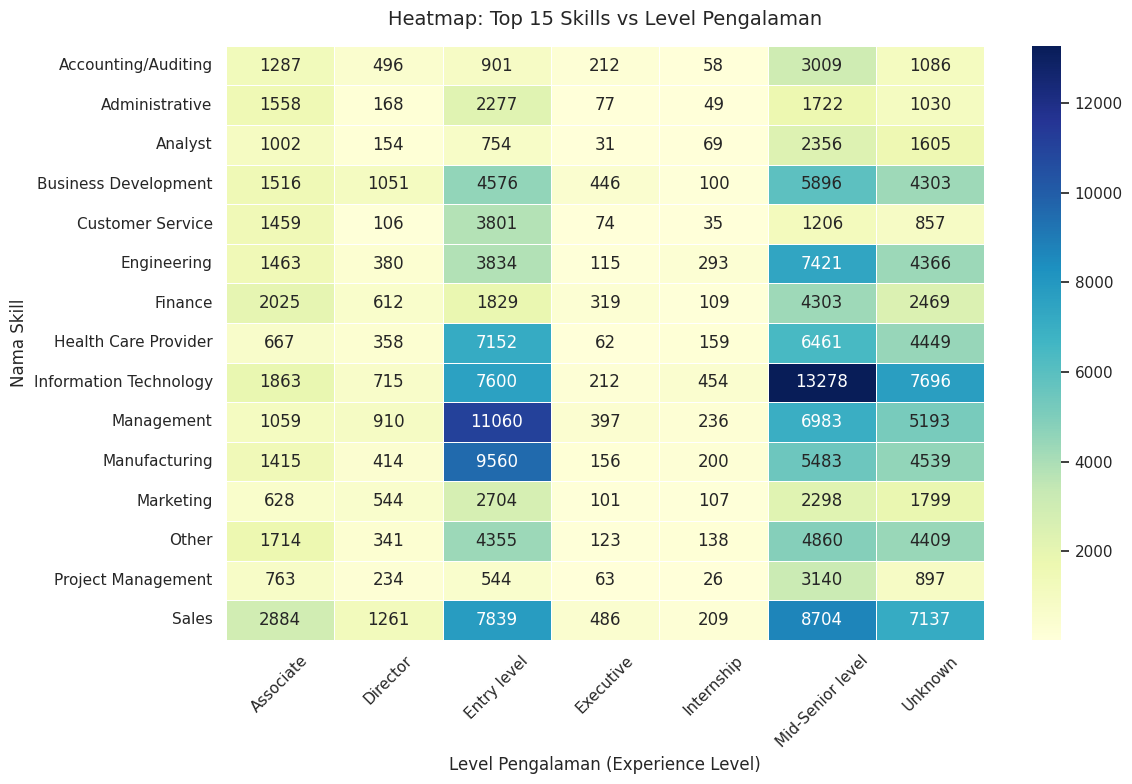

/tmp/ipykernel_3535/3143036270.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills_ind, x='count', y='skill_name', ax=axes[row, col], palette="viridis")
/tmp/ipykernel_3535/3143036270.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills_ind, x='count', y='skill_name', ax=axes[row, col], palette="viridis")
/tmp/ipykernel_3535/3143036270.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills_ind, x='count', y='skill_name', ax=axes[row, col], palette="viridis")
/tmp/ipykernel_3535/3143036270.py:40:

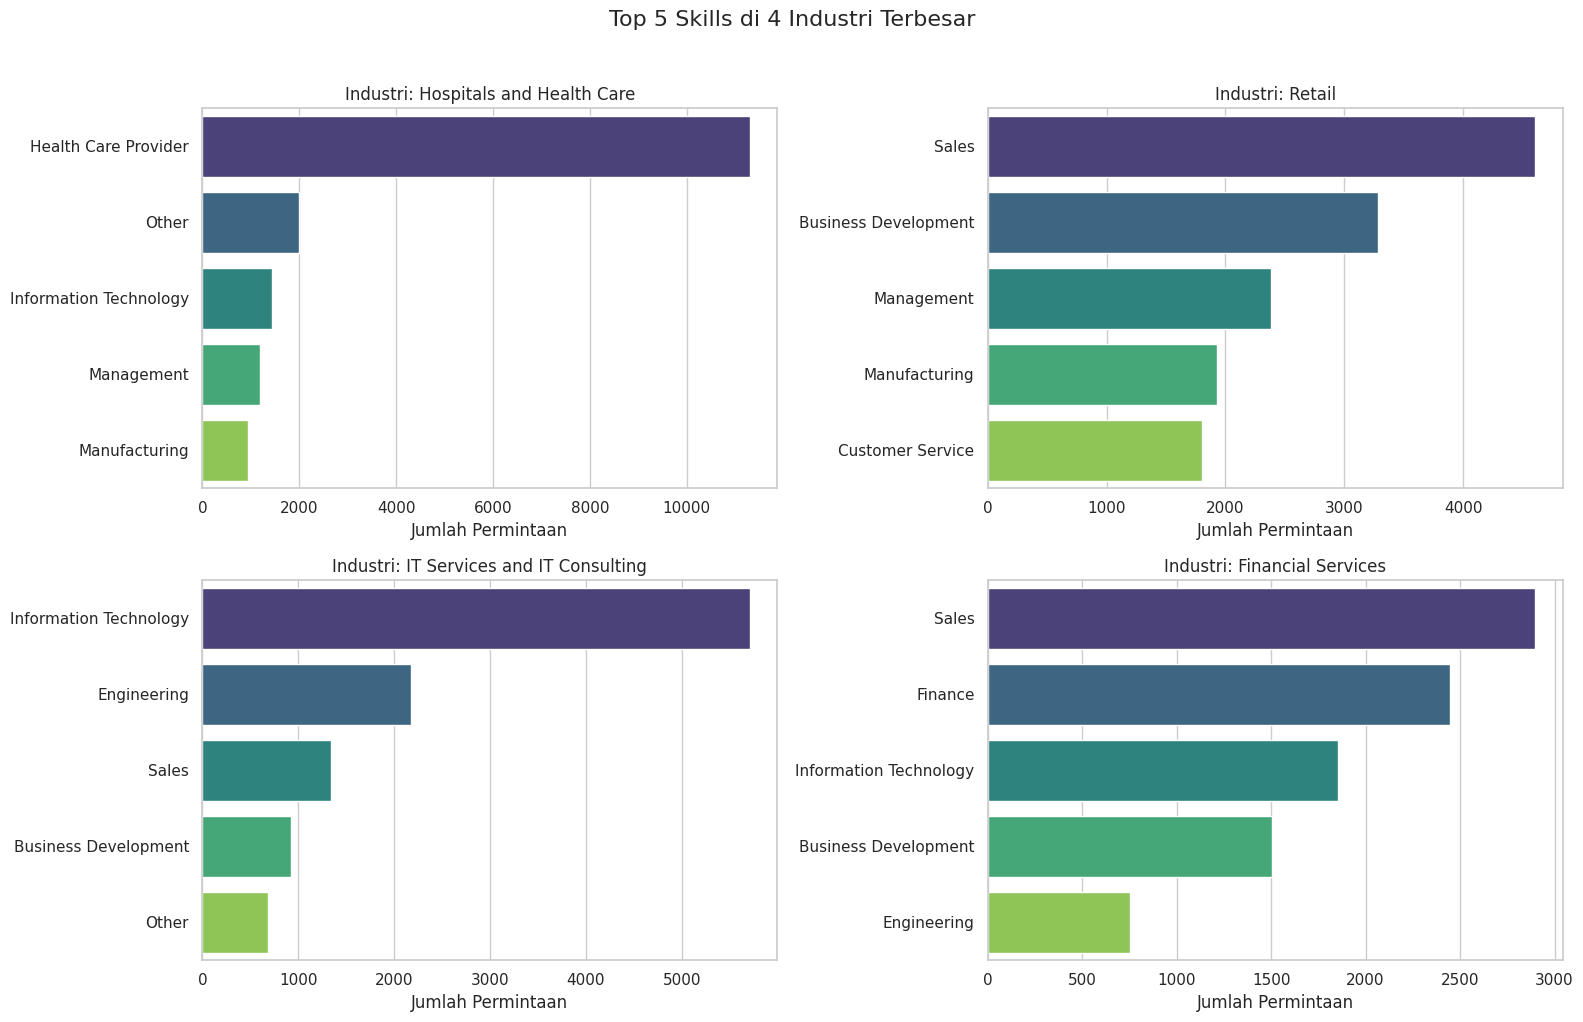

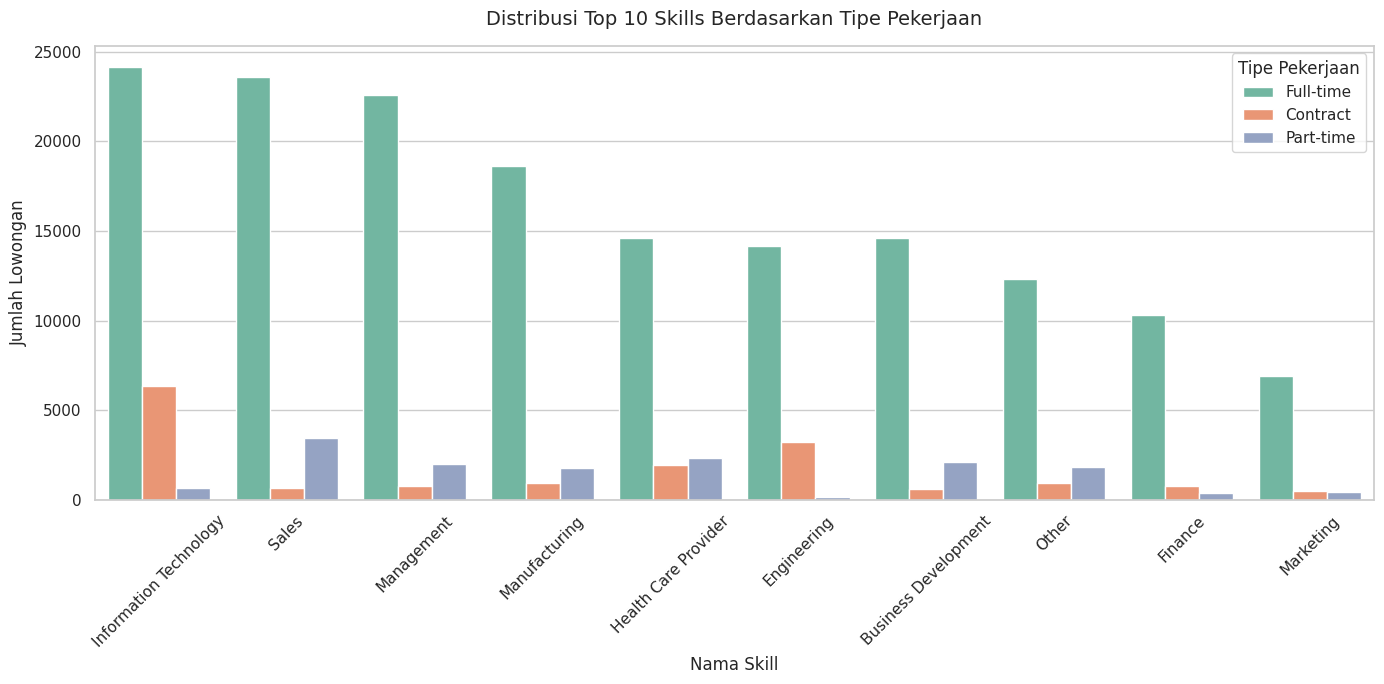

/tmp/ipykernel_3535/3143036270.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


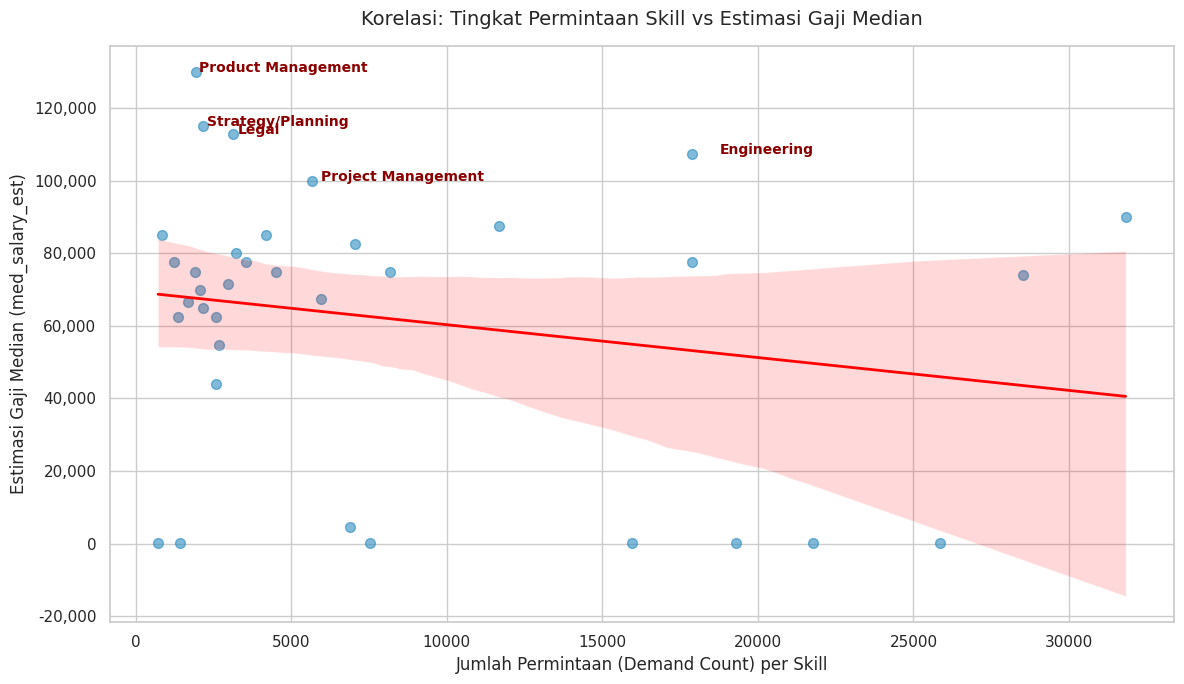

In [20]:
# Set tema visual Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# =====================================================================
# 1. VISUALISASI: TOP SKILLS BERDASARKAN LEVEL PENGALAMAN (HEATMAP)
# =====================================================================
# Mengambil top 15 skill paling populer secara keseluruhan agar heatmap tidak terlalu padat
top_15_skills_overall = df_eda_skills['skill_name'].value_counts().nlargest(15).index
df_exp_filtered = df_eda_skills[df_eda_skills['skill_name'].isin(top_15_skills_overall)]

# Membuat cross-tabulation (tabel pivot)
pivot_exp = pd.crosstab(df_exp_filtered['skill_name'], df_exp_filtered['formatted_experience_level'])

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_exp, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap: Top 15 Skills vs Level Pengalaman', fontsize=14, pad=15)
plt.ylabel('Nama Skill')
plt.xlabel('Level Pengalaman (Experience Level)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =====================================================================
# 2. VISUALISASI: TOP SKILLS PADA 4 INDUSTRI TERBESAR (SUBPLOTS)
# =====================================================================
# Cari 4 industri dengan lowongan terbanyak
top_4_industries = df_eda_skills['industry_name'].value_counts().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top 5 Skills di 4 Industri Terbesar', fontsize=16, y=1.02)

for i, industry in enumerate(top_4_industries):
    row, col = divmod(i, 2)
    # Filter data per industri dan ambil top 5 skill
    data_ind = df_eda_skills[df_eda_skills['industry_name'] == industry]
    top_skills_ind = data_ind['skill_name'].value_counts().nlargest(5).reset_index()
    top_skills_ind.columns = ['skill_name', 'count']

    sns.barplot(data=top_skills_ind, x='count', y='skill_name', ax=axes[row, col], palette="viridis")
    axes[row, col].set_title(f'Industri: {industry}')
    axes[row, col].set_xlabel('Jumlah Permintaan')
    axes[row, col].set_ylabel('')

plt.tight_layout()
plt.show()


# =====================================================================
# 3. VISUALISASI: TOP SKILLS BERDASARKAN TIPE PEKERJAAN (BARPLOT)
# =====================================================================
# Filter untuk 3 tipe pekerjaan utama (misal: Full-time, Part-time, Contract) untuk menyederhanakan
top_work_types = df_eda_skills['formatted_work_type'].value_counts().nlargest(3).index
df_wt_filtered = df_eda_skills[df_eda_skills['formatted_work_type'].isin(top_work_types)]

# Ambil top 10 skills secara keseluruhan pada tipe pekerjaan tersebut
top_10_skills_wt = df_wt_filtered['skill_name'].value_counts().nlargest(10).index
df_wt_plot = df_wt_filtered[df_wt_filtered['skill_name'].isin(top_10_skills_wt)]

plt.figure(figsize=(14, 7))
sns.countplot(data=df_wt_plot, x='skill_name', hue='formatted_work_type',
              order=top_10_skills_wt, palette="Set2")
plt.title('Distribusi Top 10 Skills Berdasarkan Tipe Pekerjaan', fontsize=14, pad=15)
plt.xlabel('Nama Skill')
plt.ylabel('Jumlah Lowongan')
plt.xticks(rotation=45)
plt.legend(title='Tipe Pekerjaan')
plt.tight_layout()
plt.show()


# =====================================================================
# 4. VISUALISASI: KORELASI DEMAND SKILL VS ESTIMASI GAJI MEDIAN (REGPLOT)
# =====================================================================
# Pastikan data skill_salary_analysis tidak memiliki nilai NaN pada sumbu x dan y
plot_data_salary = skill_salary_analysis.dropna(subset=['demand_count', 'avg_med_salary'])

plt.figure(figsize=(12, 7))
# Menggunakan regplot untuk melihat garis tren (korelasi)
sns.regplot(data=plot_data_salary, x='demand_count', y='avg_med_salary',
            scatter_kws={'alpha':0.6, 's':50, 'color':'#2b8cbe'},
            line_kws={'color':'red', 'linewidth':2})

# Menambahkan anotasi untuk skill dengan gaji tertinggi (Top 5)
top_5_salary = plot_data_salary.nlargest(5, 'avg_med_salary')
for i in range(len(top_5_salary)):
    plt.text(x=top_5_salary['demand_count'].iloc[i] * 1.05,
             y=top_5_salary['avg_med_salary'].iloc[i],
             s=top_5_salary['skill_name'].iloc[i],
             fontdict=dict(color='darkred', weight='bold', size=10))

plt.title('Korelasi: Tingkat Permintaan Skill vs Estimasi Gaji Median', fontsize=14, pad=15)
plt.xlabel('Jumlah Permintaan (Demand Count) per Skill')
plt.ylabel('Estimasi Gaji Median (med_salary_est)')

# Mengubah format sumbu Y agar lebih mudah dibaca (opsional, asumsi dalam USD/Rupiah)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

### EDA(2): Bagaimana pola rasio aplikasi terhadap views (apply-through-rate) berdasarkan kompleksitas skill, lokasi, dan kebijakan remote ?

#### exploratory

/tmp/ipykernel_3535/2227853996.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_atr, x='remote_allowed', y='atr', palette='viridis')


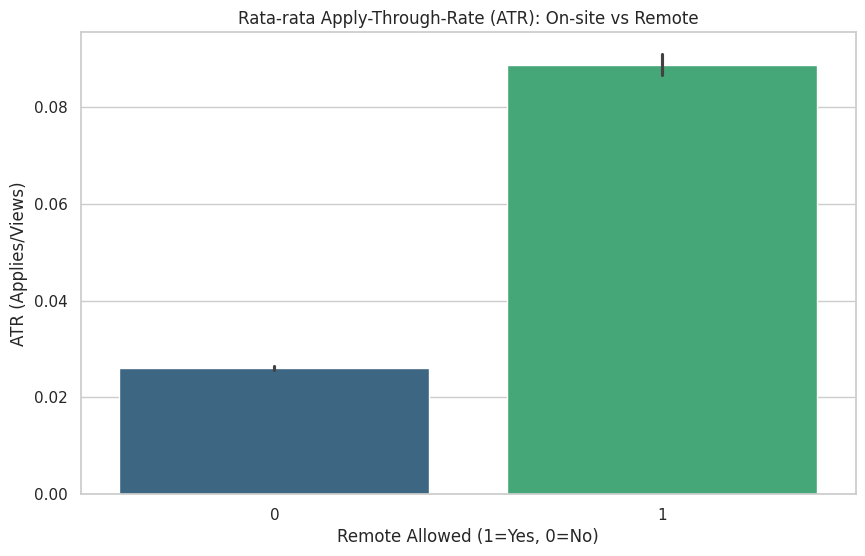

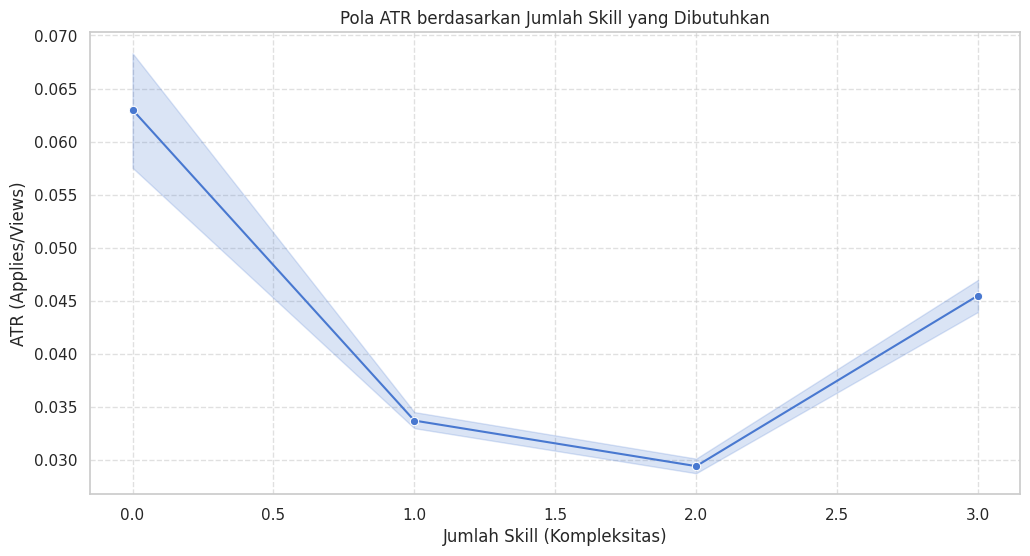

/tmp/ipykernel_3535/2227853996.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_atr, x='atr', y='location', palette='magma')


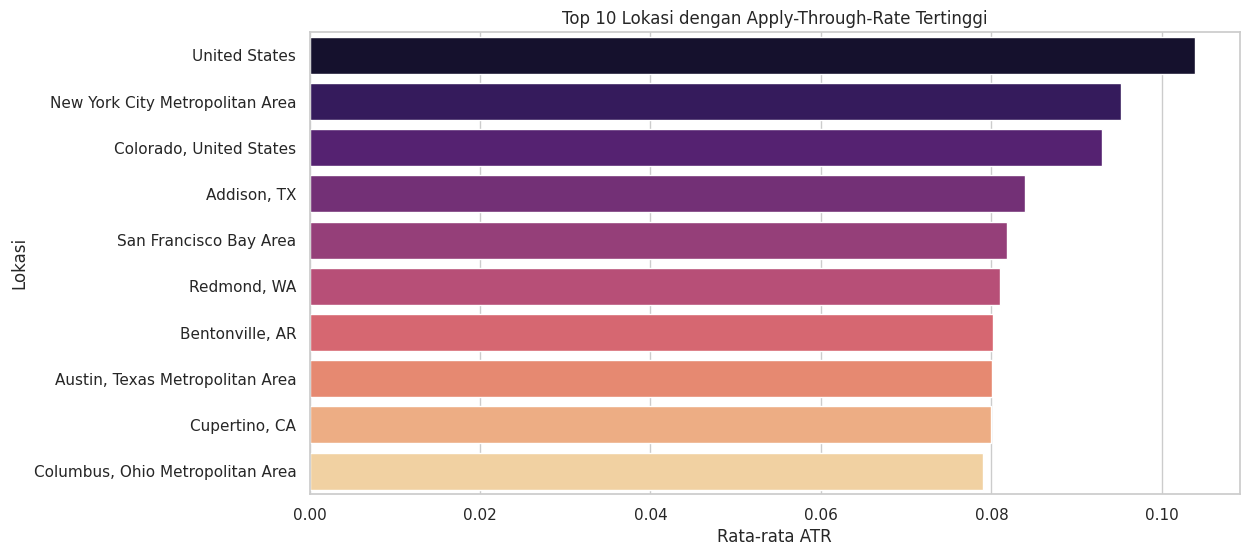

In [21]:
# 1. Menyiapkan data: Menghitung Apply-Through-Rate (ATR)
# Pastikan views > 0 untuk menghindari pembagian dengan nol
df_atr = df_posting[df_posting['views'] > 0].copy()
df_atr['atr'] = df_atr['applies'] / df_atr['views']

# 2. Menghitung Kompleksitas Skill (Jumlah skill per job_posting_id)
skill_complexity = df_job_skills.groupby('job_posting_id').size().reset_index(name='skill_count')
df_atr = df_atr.merge(skill_complexity, on='job_posting_id', how='left')
df_atr['skill_count'] = df_atr['skill_count'].fillna(0)

# 3. Visualisasi ATR berdasarkan Kebijakan Remote
plt.figure(figsize=(10, 6))
sns.barplot(data=df_atr, x='remote_allowed', y='atr', palette='viridis')
plt.title('Rata-rata Apply-Through-Rate (ATR): On-site vs Remote')
plt.xlabel('Remote Allowed (1=Yes, 0=No)')
plt.ylabel('ATR (Applies/Views)')
plt.show()

# 4. Visualisasi ATR berdasarkan Kompleksitas Skill
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_atr, x='skill_count', y='atr', marker='o')
plt.title('Pola ATR berdasarkan Jumlah Skill yang Dibutuhkan')
plt.xlabel('Jumlah Skill (Kompleksitas)')
plt.ylabel('ATR (Applies/Views)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Visualisasi ATR berdasarkan Lokasi (Top 10 Lokasi dengan ATR tertinggi)
# Mengambil lokasi dengan jumlah postingan yang cukup (misal > 50) agar data stabil
location_counts = df_atr['location'].value_counts()
top_locations = location_counts[location_counts > 50].index
df_loc_filtered = df_atr[df_atr['location'].isin(top_locations)]

loc_atr = df_loc_filtered.groupby('location')['atr'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=loc_atr, x='atr', y='location', palette='magma')
plt.title('Top 10 Lokasi dengan Apply-Through-Rate Tertinggi')
plt.xlabel('Rata-rata ATR')
plt.ylabel('Lokasi')
plt.show()

#### explanatory

/tmp/ipykernel_3535/2227853996.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_atr, x='remote_allowed', y='atr', palette='viridis')


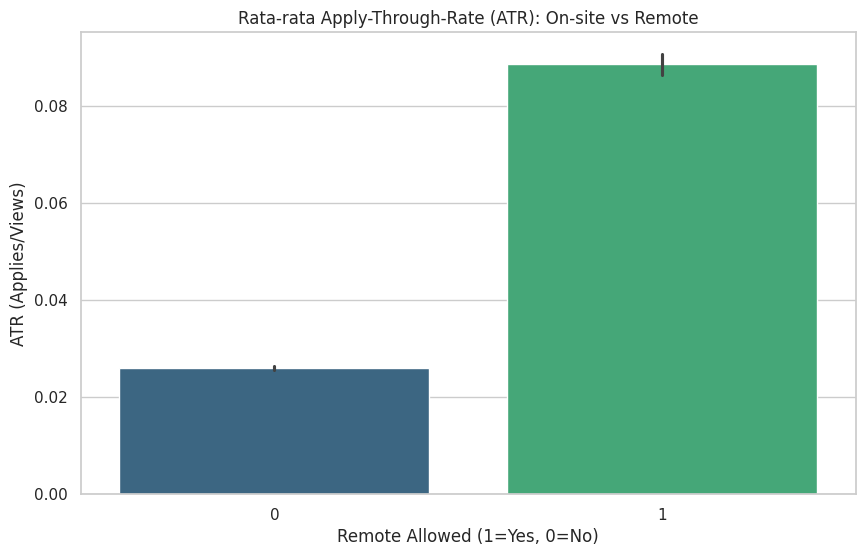

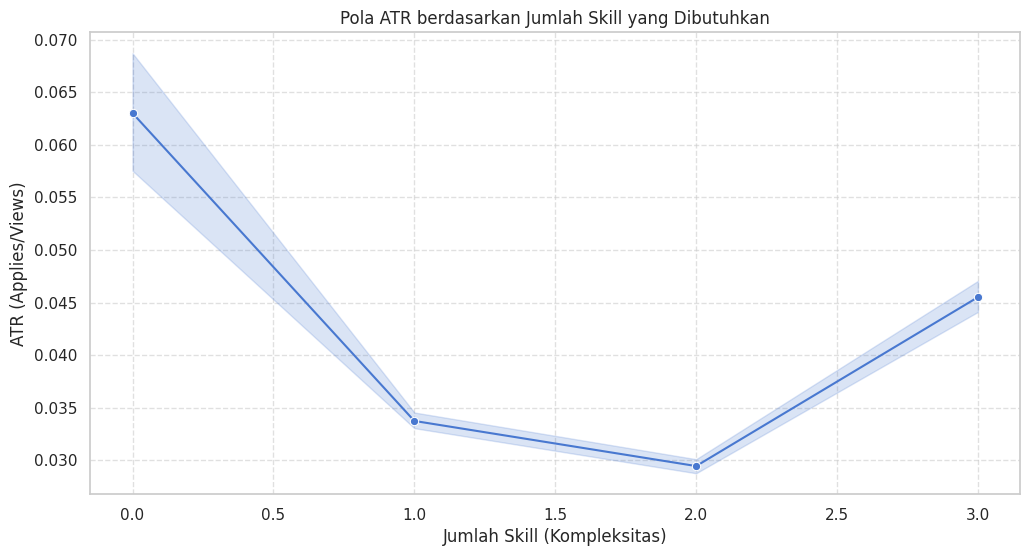

/tmp/ipykernel_3535/2227853996.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_atr, x='atr', y='location', palette='magma')


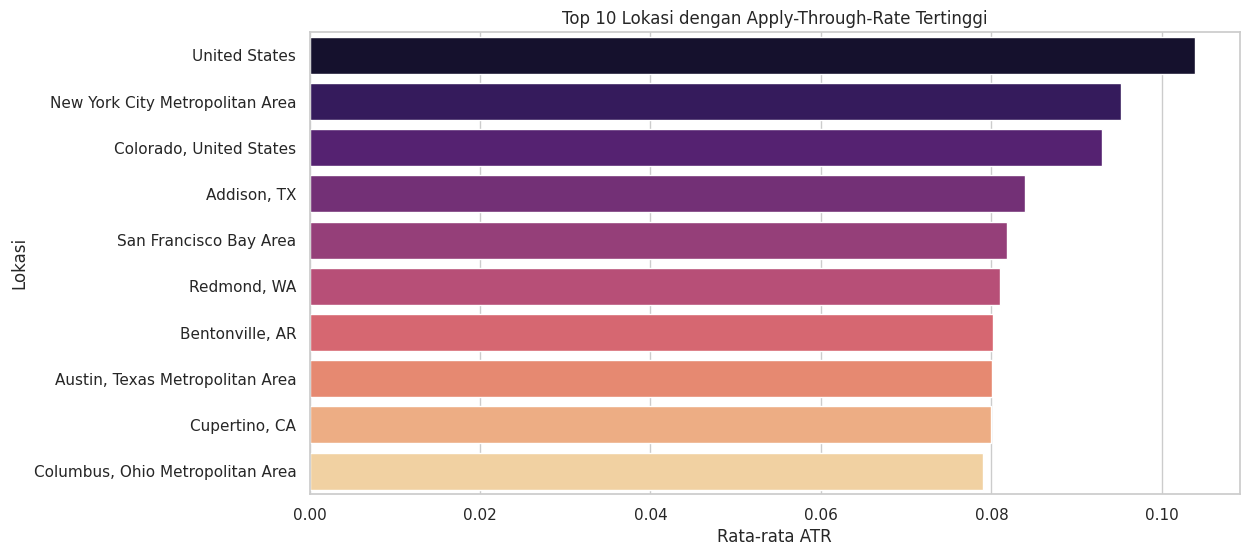

In [22]:
# 1. Menyiapkan data: Menghitung Apply-Through-Rate (ATR)
# Pastikan views > 0 untuk menghindari pembagian dengan nol
df_atr = df_posting[df_posting['views'] > 0].copy()
df_atr['atr'] = df_atr['applies'] / df_atr['views']

# 2. Menghitung Kompleksitas Skill (Jumlah skill per job_posting_id)
skill_complexity = df_job_skills.groupby('job_posting_id').size().reset_index(name='skill_count')
df_atr = df_atr.merge(skill_complexity, on='job_posting_id', how='left')
df_atr['skill_count'] = df_atr['skill_count'].fillna(0)

# 3. Visualisasi ATR berdasarkan Kebijakan Remote
plt.figure(figsize=(10, 6))
sns.barplot(data=df_atr, x='remote_allowed', y='atr', palette='viridis')
plt.title('Rata-rata Apply-Through-Rate (ATR): On-site vs Remote')
plt.xlabel('Remote Allowed (1=Yes, 0=No)')
plt.ylabel('ATR (Applies/Views)')
plt.show()

# 4. Visualisasi ATR berdasarkan Kompleksitas Skill
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_atr, x='skill_count', y='atr', marker='o')
plt.title('Pola ATR berdasarkan Jumlah Skill yang Dibutuhkan')
plt.xlabel('Jumlah Skill (Kompleksitas)')
plt.ylabel('ATR (Applies/Views)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Visualisasi ATR berdasarkan Lokasi (Top 10 Lokasi dengan ATR tertinggi)
# Mengambil lokasi dengan jumlah postingan yang cukup (misal > 50) agar data stabil
location_counts = df_atr['location'].value_counts()
top_locations = location_counts[location_counts > 50].index
df_loc_filtered = df_atr[df_atr['location'].isin(top_locations)]

loc_atr = df_loc_filtered.groupby('location')['atr'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=loc_atr, x='atr', y='location', palette='magma')
plt.title('Top 10 Lokasi dengan Apply-Through-Rate Tertinggi')
plt.xlabel('Rata-rata ATR')
plt.ylabel('Lokasi')
plt.show()

### EDA(3): Skill apa yang sering muncul bersamaan (co-occurrence) dalam satu lowongan, dan kombinasi mana yang paling prediktif terhadap gaji tinggi atau penutupan lowongan yang cepat ?

#### exploratory


LOADING DATA
✓ job_posting: (123849, 21)
✓ skills: (35, 2)
✓ job_skills: (213768, 3)
✓ salaries: (40785, 9)

DATA CLEANING
✓ Data cleaning selesai!

FEATURE ENGINEERING
✓ Merged job_skills dengan skills: (213768, 4)
✓ Merged dengan job_posting: (213768, 13)
✓ Merged dengan salaries: (213768, 17)

FEATURE ENGINEERING: TARGET VARIABLES
Salary Threshold (75th percentile): $116,300

Total job postings dengan closed_time: 1409
Quick Closure Threshold (25th percentile): 0 hari

High Salary Distribution:
high_salary
0    196624
1     17144
Name: count, dtype: int64

Quick Closure Distribution:
quick_closure
1    1361
0      48
Name: count, dtype: int64

ANALISIS 1: DISTRIBUSI SKILL

Total unique skills: 35

Top 15 Most Common Skills:
skill_name
Information Technology    26137
Sales                     22475
Management                20861
Manufacturing             18185
Health Care Provider      17369
Business Development      14290
Engineering               13009
Other                     1

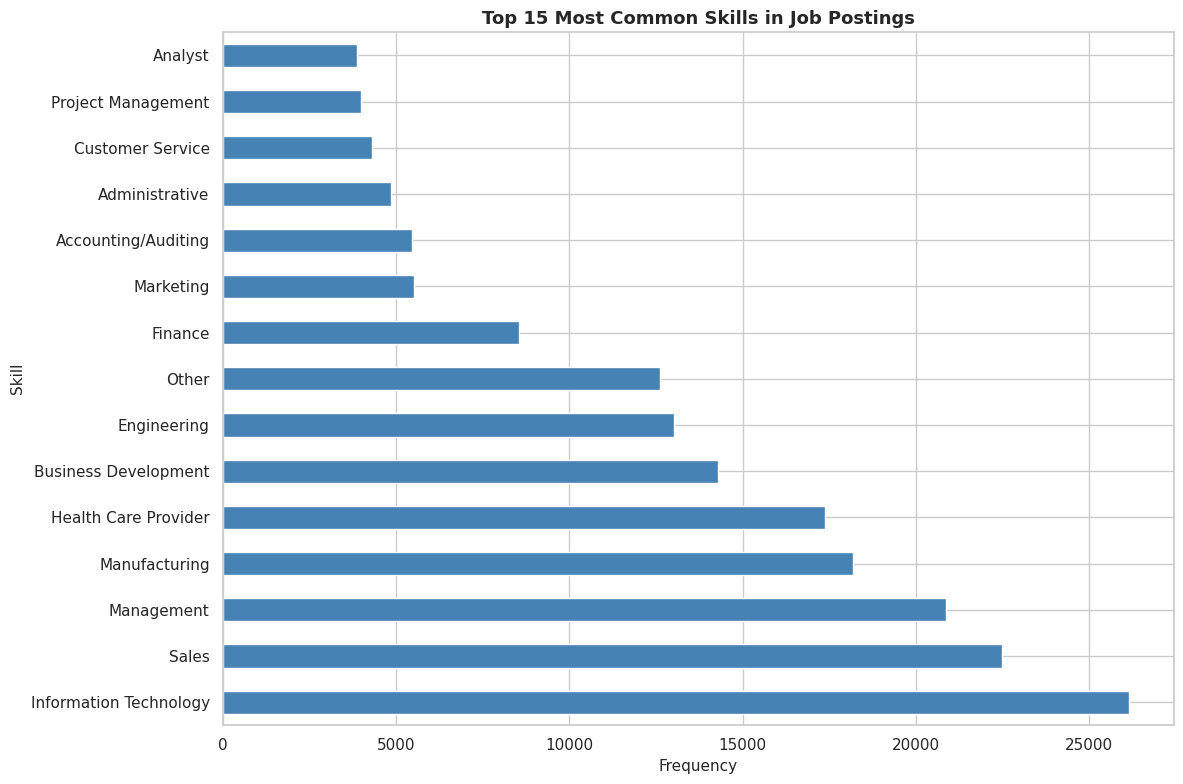

✓ Saved: 01_top_skills_distribution.png

ANALISIS 2: CO-OCCURRENCE SKILL PAIRS
Total job postings dengan skill data: 126807

Top 20 Skill Co-occurrence Pairs:
 1. Management           + Manufacturing        = 16336 occurrences
 2. Business Development + Sales                = 13164 occurrences
 3. Engineering          + Information Technology =  9090 occurrences
 4. Accounting/Auditing  + Finance              =  3735 occurrences
 5. Finance              + Sales                =  3569 occurrences
 6. Marketing            + Sales                =  2340 occurrences
 7. Analyst              + Research             =  2242 occurrences
 8. Analyst              + Information Technology =  2196 occurrences
 9. Information Technology + Project Management   =  2144 occurrences
10. Information Technology + Research             =  1959 occurrences
11. Education            + Training             =  1833 occurrences
12. Art/Creative         + Design               =  1466 occurrences
13. Design       

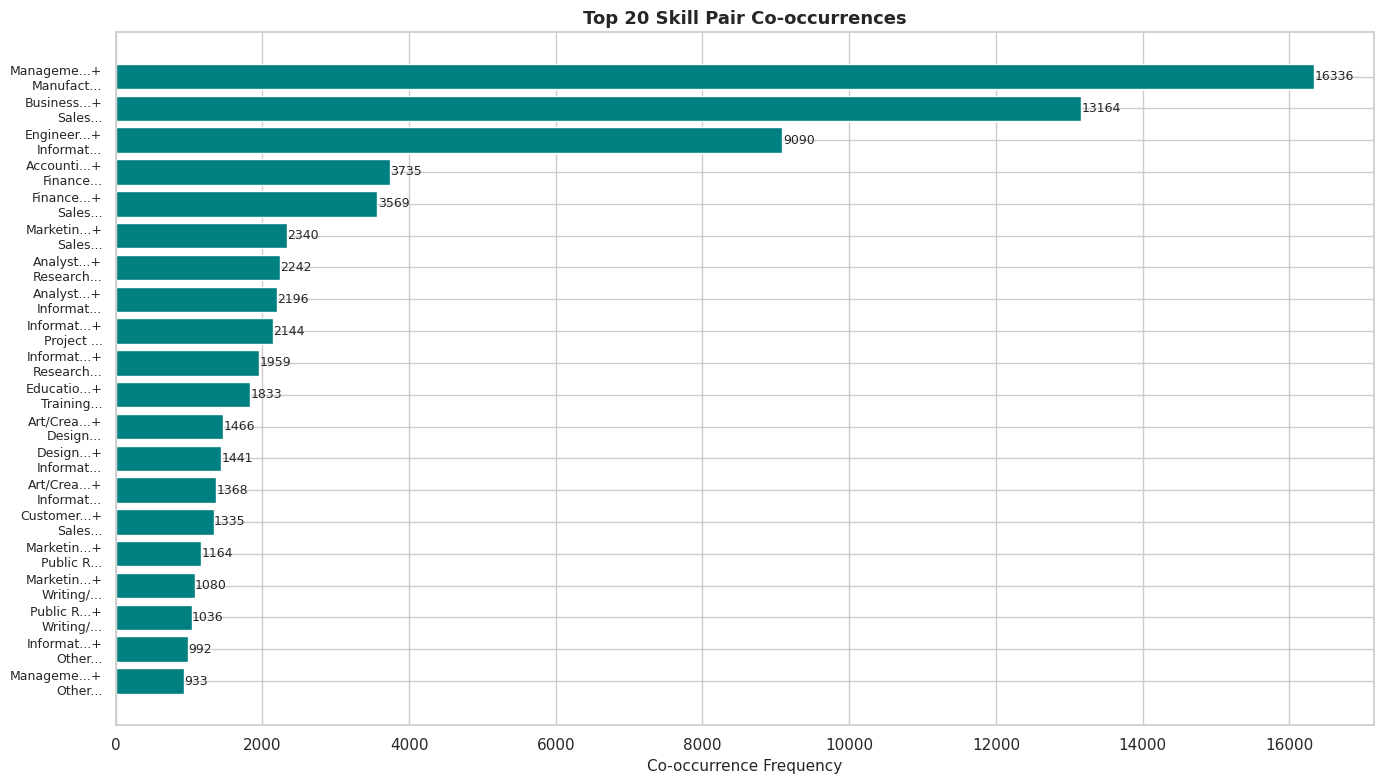


✓ Saved: 02_skill_pairs_cooccurrence.png

ANALISIS 3: SKILL PAIRS vs GAJI TINGGI

Top 15 Skill Pairs dengan Highest High-Salary Rate:
Skill Pair 1         Skill Pair 2         Count    High-Salary %  
-----------------------------------------------------------------
Engineering          Information Technology 9090       14.8%
Information Technology Project Management   2144       13.9%
Accounting/Auditing  Finance              3735       12.2%
Information Technology Research             1959       10.4%
Analyst              Information Technology 2196        9.7%
Marketing            Public Relations     1164        9.1%
Finance              Sales                3569        8.7%
Business Development Sales                13164       8.2%
Analyst              Research             2242        8.2%
Art/Creative         Design               1466        7.0%
Design               Information Technology 1441        6.5%
Marketing            Sales                2340        6.5%
Art/Creative  

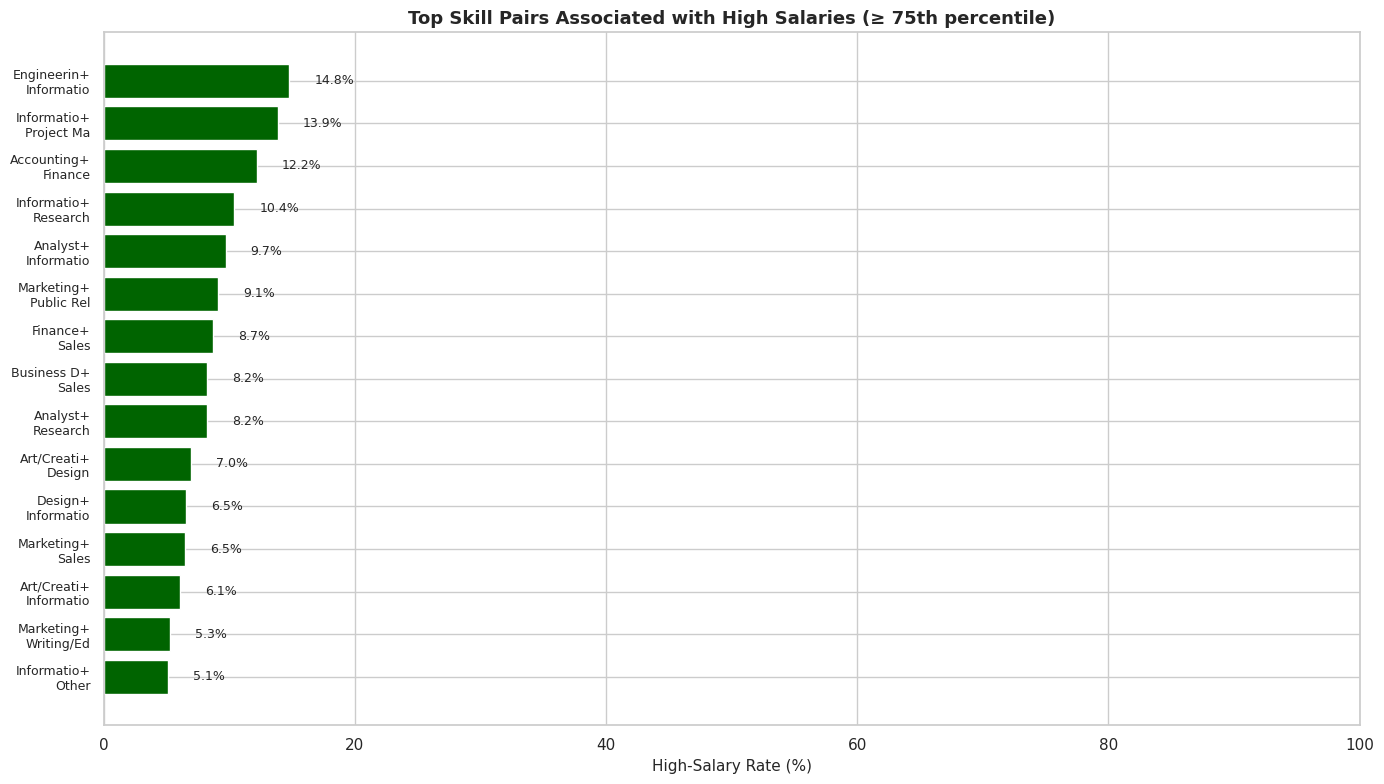


✓ Saved: 03_skill_pairs_high_salary.png

ANALISIS 4: SKILL PAIRS vs PENUTUPAN CEPAT

Top 15 Skill Pairs dengan Highest Quick-Closure Rate:
Skill Pair 1         Skill Pair 2         Count    Quick-Closure %
-----------------------------------------------------------------
Engineering          Information Technology 9090        0.7%
Marketing            Sales                2340        0.7%
Public Relations     Writing/Editing      1036        0.7%
Marketing            Writing/Editing      1080        0.6%
Management           Other                933         0.6%
Information Technology Other                992         0.6%
Marketing            Public Relations     1164        0.6%
Customer Service     Sales                1335        0.5%
Information Technology Project Management   2144        0.4%
Design               Information Technology 1441        0.4%
Analyst              Information Technology 2196        0.4%
Analyst              Research             2242        0.4%
Art/Creat

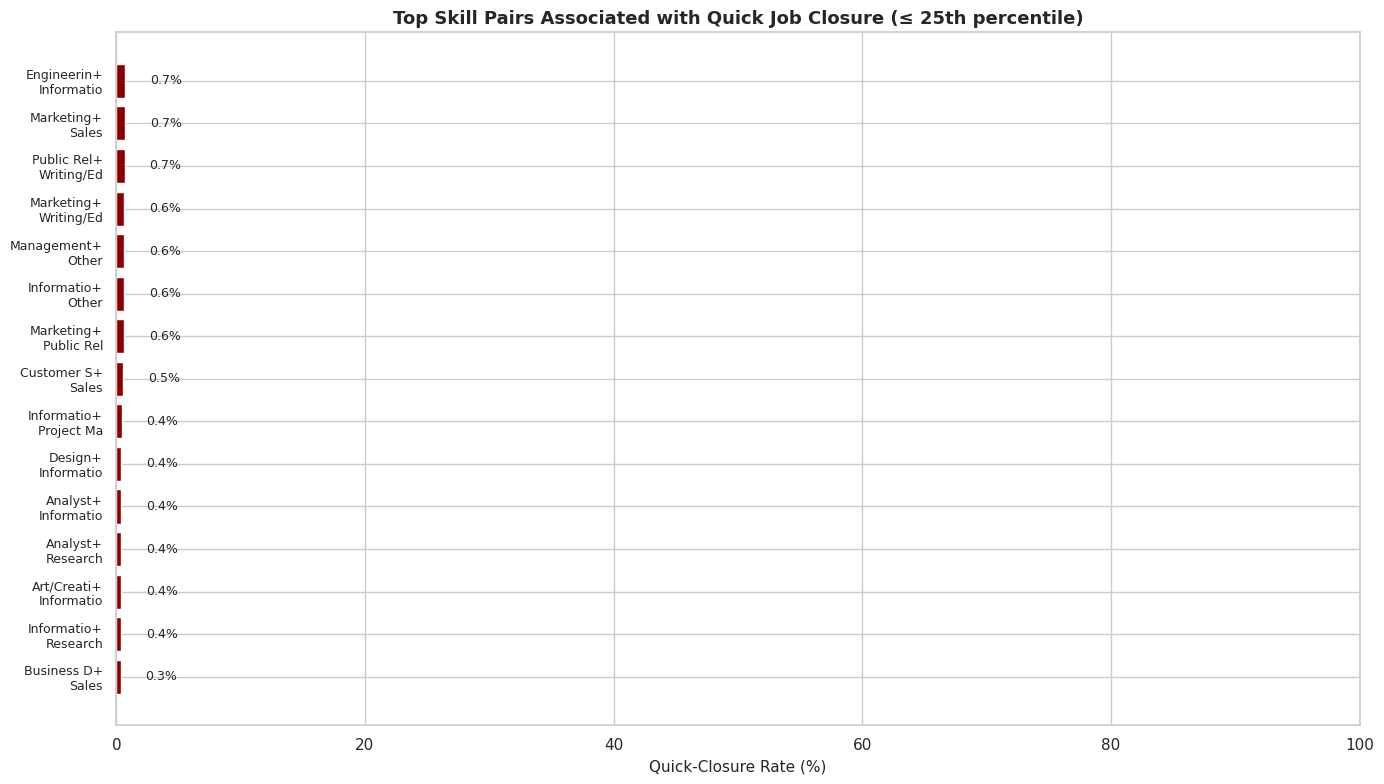


✓ Saved: 04_skill_pairs_quick_closure.png

ANALISIS 5: SKILL COMBINATIONS (3+ SKILLS)

Top 10 Skill Triplets Co-occurrence:
 1. Analyst            + Information Technology + Research           = 1891
 2. Art/Creative       + Design             + Information Technology = 1340
 3. Marketing          + Public Relations   + Writing/Editing    = 1029
 4. Information Technology + Management         + Other              =  795
 5. Consulting         + Information Technology + Sales              =  414
 6. Customer Service   + Management         + Marketing          =  337
 7. Analyst            + Engineering        + Research           =  204
 8. Consulting         + Engineering        + Information Technology =  176
 9. Business Development + Customer Service   + Sales              =  174
10. Business Development + Consulting         + Sales              =  170

Correlation Triplets dengan High Salary:
Skill 1            Skill 2            Skill 3            Count    High-Salary %  
-------

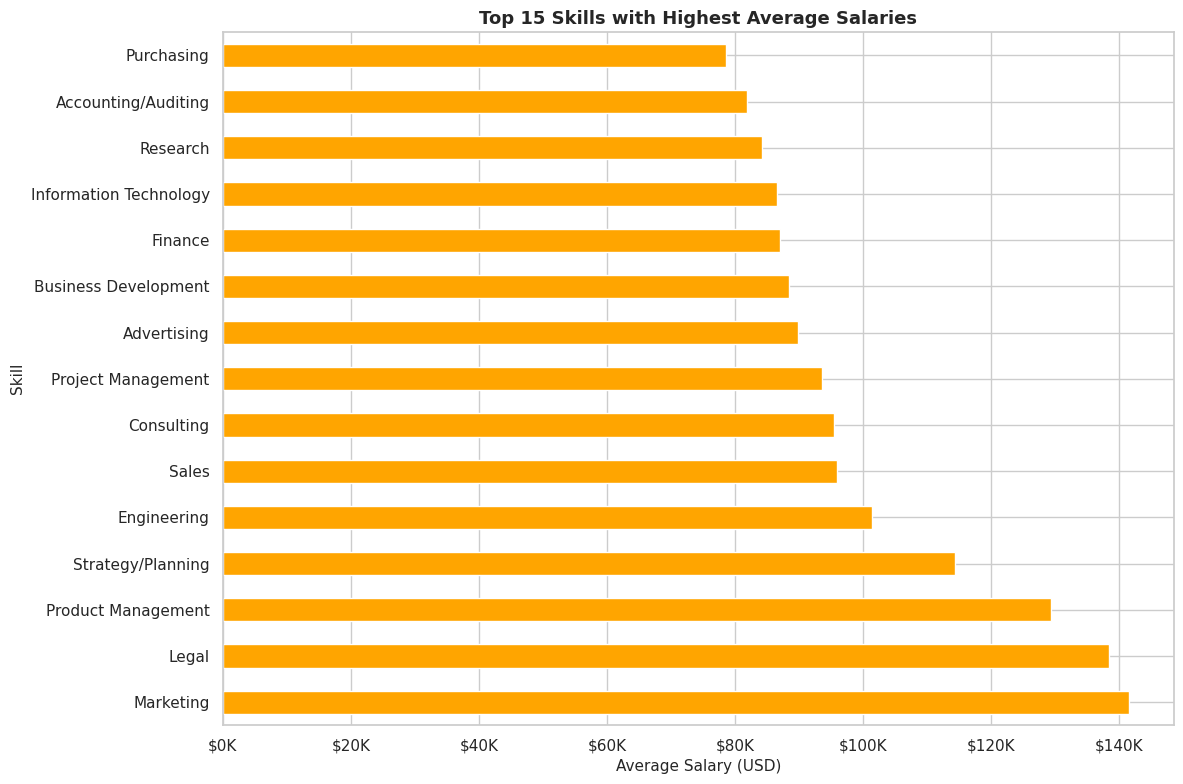


✓ Saved: 05_skills_average_salary.png

ANALISIS 7: SUMMARY TABLE - TOP SKILL PAIRS & OUTCOMES

 Rank                Skill_1                Skill_2  Total_Occurrences  High_Salary_Count  High_Salary_Rate_%  Quick_Closure_Count  Quick_Closure_Rate_%
    1             Management          Manufacturing              16336                429                2.63                   45                  0.28
    2   Business Development                  Sales              13164               1085                8.24                   45                  0.34
    3            Engineering Information Technology               9090               1344               14.79                   67                  0.74
    4    Accounting/Auditing                Finance               3735                455               12.18                   11                  0.29
    5                Finance                  Sales               3569                312                8.74                   12         

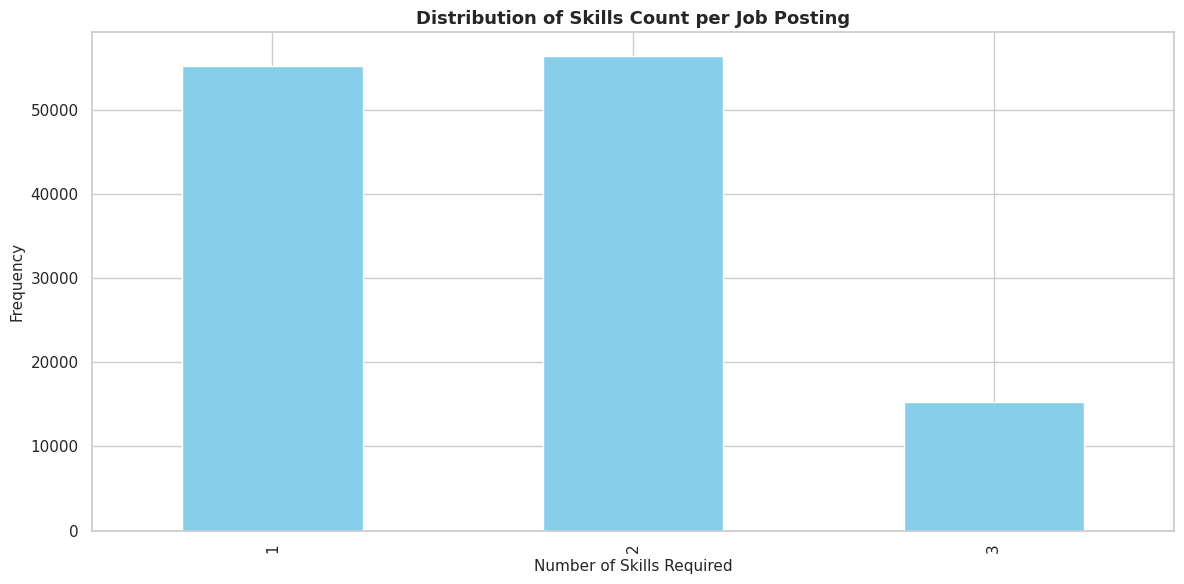

✓ Saved: 06_skills_count_distribution.png

ANALISIS 9: SINGLE SKILL PREDICTIVENESS

Top 20 Skills - Predictiveness Analysis:
                 Skill  Frequency  Avg_Salary_USD  High_Salary_Rate_%  Quick_Closure_Rate_%
Information Technology      26137         86520.0               36.97                 93.99
                 Sales      22475         95913.0               25.96                 90.11
            Management      20861         46364.0               14.85                 96.88
         Manufacturing      18185         36070.0               10.32                 96.00
  Health Care Provider      17369         40693.0               14.87                100.00
  Business Development      14290         88429.0               28.57                 92.59
           Engineering      13009        101390.0               43.72                 96.63
                 Other      12608         44730.0               13.32                 91.30
               Finance       8540         87041

In [23]:
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load datasets
df_posting
df_skills
df_job_skills
df_salaries

print(f"✓ job_posting: {df_posting.shape}")
print(f"✓ skills: {df_skills.shape}")
print(f"✓ job_skills: {df_job_skills.shape}")
print(f"✓ salaries: {df_salaries.shape}")

# ================================================================================
# DATA CLEANING (sesuai dengan kode yang sudah diberikan)
# ================================================================================
print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

# Cleaning df_posting
time_cols_posting = ['original_listed_time', 'expiry', 'closed_time', 'listed_time']
for col in time_cols_posting:
    df_posting[col] = pd.to_datetime(df_posting[col], unit='ms', errors='coerce')

df_posting['company_id'] = df_posting['company_id'].astype('Int64')

text_cols_posting = ['job_description', 'formatted_experience_level', 'skills_desc', 'posting_domain', 'application_url']
for col in text_cols_posting:
    df_posting[col] = df_posting[col].fillna('Unknown')

df_posting['remote_allowed'] = df_posting['remote_allowed'].fillna(0).astype('Int64')

# Cleaning df_salaries
df_salaries['med_salary_est'] = df_salaries['med_salary'].fillna(
    (df_salaries['min_salary'] + df_salaries['max_salary']) / 2
)

print("✓ Data cleaning selesai!")

# ================================================================================
# FEATURE ENGINEERING: MERGE & PREPROCESSING
# ================================================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 1. Merge job_skills dengan skills untuk mendapatkan nama skill
df_job_skills_merged = df_job_skills.merge(df_skills, on='skill_id', how='left')
print(f"✓ Merged job_skills dengan skills: {df_job_skills_merged.shape}")

# 2. Merge dengan job_posting untuk mendapatkan informasi lowongan
df_analysis = df_job_skills_merged.merge(
    df_posting[['job_posting_id', 'title', 'views', 'applies', 'original_listed_time',
                'expiry', 'closed_time', 'formatted_experience_level', 'remote_allowed',
                'formatted_work_type']],
    on='job_posting_id',
    how='left'
)
print(f"✓ Merged dengan job_posting: {df_analysis.shape}")

# 3. Merge dengan salary data
df_analysis = df_analysis.merge(
    df_salaries[['job_posting_id', 'med_salary_est', 'min_salary', 'max_salary', 'pay_period']],
    on='job_posting_id',
    how='left'
)
print(f"✓ Merged dengan salaries: {df_analysis.shape}")

# ================================================================================
# FEATURE ENGINEERING: GAJI TINGGI & PENUTUPAN CEPAT
# ================================================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING: TARGET VARIABLES")
print("="*80)

# 1. GAJI TINGGI: Tentukan threshold berdasarkan percentile 75
salary_threshold = df_analysis['med_salary_est'].quantile(0.75)
print(f"Salary Threshold (75th percentile): ${salary_threshold:,.0f}")
df_analysis['high_salary'] = (df_analysis['med_salary_est'] >= salary_threshold).astype(int)

# 2. PENUTUPAN CEPAT:
# Hitung duration = closed_time - original_listed_time (dalam hari)
df_analysis['listing_duration'] = (
    (df_analysis['closed_time'] - df_analysis['original_listed_time']).dt.days
)

# Filter hanya yang ada closed_time (actual closures)
df_with_closure = df_analysis[df_analysis['closed_time'].notna()].copy()
print(f"\nTotal job postings dengan closed_time: {len(df_with_closure)}")

# Tentukan threshold untuk penutupan cepat (percentile 25 = 25% tercepat)
closure_threshold = df_with_closure['listing_duration'].quantile(0.25)
print(f"Quick Closure Threshold (25th percentile): {closure_threshold:.0f} hari")
df_with_closure['quick_closure'] = (df_with_closure['listing_duration'] <= closure_threshold).astype(int)

print(f"\nHigh Salary Distribution:\n{df_analysis['high_salary'].value_counts()}")
print(f"\nQuick Closure Distribution:\n{df_with_closure['quick_closure'].value_counts()}")

# ================================================================================
# ANALISIS 1: DISTRIBUSI SKILL
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 1: DISTRIBUSI SKILL")
print("="*80)

# Count skill frequency
skill_counts = df_analysis['skill_name'].value_counts()
print(f"\nTotal unique skills: {len(skill_counts)}")
print(f"\nTop 15 Most Common Skills:")
print(skill_counts.head(15))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))
skill_counts.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Frequency', fontsize=11)
ax.set_ylabel('Skill', fontsize=11)
ax.set_title('Top 15 Most Common Skills in Job Postings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 01_top_skills_distribution.png")

# ================================================================================
# ANALISIS 2: CO-OCCURRENCE SKILL PAIRS
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 2: CO-OCCURRENCE SKILL PAIRS")
print("="*80)

# Groupby job_posting_id untuk mendapatkan skill combinations per lowongan
job_skills_dict = df_analysis.groupby('job_posting_id')['skill_name'].apply(list).to_dict()
print(f"Total job postings dengan skill data: {len(job_skills_dict)}")

# Hitung skill pairs (kombinasi 2 skill)
skill_pairs = Counter()
for job_id, skills in job_skills_dict.items():
    if len(skills) >= 2:
        # Generate semua kombinasi 2 skill
        pairs = combinations(sorted(set(skills)), 2)
        for pair in pairs:
            skill_pairs[pair] += 1

# Top 20 skill pairs
top_skill_pairs = skill_pairs.most_common(20)
print(f"\nTop 20 Skill Co-occurrence Pairs:")
for idx, (pair, count) in enumerate(top_skill_pairs, 1):
    print(f"{idx:2d}. {pair[0]:20s} + {pair[1]:20s} = {count:5d} occurrences")

# Visualisasi
pair_names = [f"{p[0][:8]}...+\n{p[1][:8]}..." for p, _ in top_skill_pairs]
pair_counts = [count for _, count in top_skill_pairs]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(pair_names)), pair_counts, color='teal')
ax.set_yticks(range(len(pair_names)))
ax.set_yticklabels(pair_names, fontsize=9)
ax.set_xlabel('Co-occurrence Frequency', fontsize=11)
ax.set_title('Top 20 Skill Pair Co-occurrences', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (bar, count) in enumerate(zip(bars, pair_counts)):
    ax.text(count + 5, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()
print("\n✓ Saved: 02_skill_pairs_cooccurrence.png")

# ================================================================================
# ANALISIS 3: SKILL PAIRS vs GAJI TINGGI
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 3: SKILL PAIRS vs GAJI TINGGI")
print("="*80)

# Create dataset dengan salary info
df_for_salary = df_analysis[df_analysis['med_salary_est'].notna()].copy()

# Mapping job_posting_id ke high_salary status
salary_map = dict(zip(df_for_salary['job_posting_id'], df_for_salary['high_salary']))

# Hitung high_salary rate untuk setiap skill pair
pair_salary_stats = {}
for pair, count in top_skill_pairs[:20]:
    high_salary_count = 0
    total_count = 0

    for job_id, skills in job_skills_dict.items():
        if pair[0] in skills and pair[1] in skills:
            total_count += 1
            if job_id in salary_map and salary_map[job_id] == 1:
                high_salary_count += 1

    if total_count > 0:
        high_salary_rate = high_salary_count / total_count
        pair_salary_stats[pair] = {
            'total': total_count,
            'high_salary_count': high_salary_count,
            'high_salary_rate': high_salary_rate
        }

# Sort by high_salary_rate
sorted_pairs_salary = sorted(pair_salary_stats.items(),
                            key=lambda x: x[1]['high_salary_rate'],
                            reverse=True)

print(f"\nTop 15 Skill Pairs dengan Highest High-Salary Rate:")
print(f"{'Skill Pair 1':<20} {'Skill Pair 2':<20} {'Count':<8} {'High-Salary %':<15}")
print("-" * 65)
for idx, (pair, stats) in enumerate(sorted_pairs_salary[:15], 1):
    print(f"{pair[0]:<20} {pair[1]:<20} {stats['total']:<8} {stats['high_salary_rate']*100:>6.1f}%")

# Visualisasi
top_15_pairs_salary = sorted_pairs_salary[:15]
pair_labels = [f"{p[0][:10]}+\n{p[1][:10]}" for p, _ in top_15_pairs_salary]
high_salary_rates = [stats['high_salary_rate']*100 for _, stats in top_15_pairs_salary]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(pair_labels)), high_salary_rates, color='darkgreen')
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels, fontsize=9)
ax.set_xlabel('High-Salary Rate (%)', fontsize=11)
ax.set_title('Top Skill Pairs Associated with High Salaries (≥ 75th percentile)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim([0, 100])

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, high_salary_rates)):
    ax.text(rate + 2, i, f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()
print("\n✓ Saved: 03_skill_pairs_high_salary.png")

# ================================================================================
# ANALISIS 4: SKILL PAIRS vs PENUTUPAN CEPAT
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 4: SKILL PAIRS vs PENUTUPAN CEPAT")
print("="*80)

# Mapping job_posting_id ke quick_closure status
closure_map = dict(zip(df_with_closure['job_posting_id'], df_with_closure['quick_closure']))

# Hitung quick_closure rate untuk setiap skill pair
pair_closure_stats = {}
for pair, count in top_skill_pairs[:20]:
    quick_closure_count = 0
    total_count = 0

    for job_id, skills in job_skills_dict.items():
        if pair[0] in skills and pair[1] in skills:
            total_count += 1
            if job_id in closure_map and closure_map[job_id] == 1:
                quick_closure_count += 1

    if total_count > 0:
        quick_closure_rate = quick_closure_count / total_count
        pair_closure_stats[pair] = {
            'total': total_count,
            'quick_closure_count': quick_closure_count,
            'quick_closure_rate': quick_closure_rate
        }

# Sort by quick_closure_rate
sorted_pairs_closure = sorted(pair_closure_stats.items(),
                             key=lambda x: x[1]['quick_closure_rate'],
                             reverse=True)

print(f"\nTop 15 Skill Pairs dengan Highest Quick-Closure Rate:")
print(f"{'Skill Pair 1':<20} {'Skill Pair 2':<20} {'Count':<8} {'Quick-Closure %':<15}")
print("-" * 65)
for idx, (pair, stats) in enumerate(sorted_pairs_closure[:15], 1):
    print(f"{pair[0]:<20} {pair[1]:<20} {stats['total']:<8} {stats['quick_closure_rate']*100:>6.1f}%")

# Visualisasi
top_15_pairs_closure = sorted_pairs_closure[:15]
pair_labels_closure = [f"{p[0][:10]}+\n{p[1][:10]}" for p, _ in top_15_pairs_closure]
quick_closure_rates = [stats['quick_closure_rate']*100 for _, stats in top_15_pairs_closure]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(pair_labels_closure)), quick_closure_rates, color='darkred')
ax.set_yticks(range(len(pair_labels_closure)))
ax.set_yticklabels(pair_labels_closure, fontsize=9)
ax.set_xlabel('Quick-Closure Rate (%)', fontsize=11)
ax.set_title('Top Skill Pairs Associated with Quick Job Closure (≤ 25th percentile)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim([0, 100])

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, quick_closure_rates)):
    ax.text(rate + 2, i, f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()
print("\n✓ Saved: 04_skill_pairs_quick_closure.png")

# ================================================================================
# ANALISIS 5: SKILL COMBINATIONS (3+ SKILLS)
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 5: SKILL COMBINATIONS (3+ SKILLS)")
print("="*80)

# Hitung skill triplets (kombinasi 3 skill)
skill_triplets = Counter()
for job_id, skills in job_skills_dict.items():
    if len(skills) >= 3:
        triplets = combinations(sorted(set(skills)), 3)
        for triplet in triplets:
            skill_triplets[triplet] += 1

# Top 10 skill triplets
top_skill_triplets = skill_triplets.most_common(10)
print(f"\nTop 10 Skill Triplets Co-occurrence:")
for idx, (triplet, count) in enumerate(top_skill_triplets, 1):
    print(f"{idx:2d}. {triplet[0]:18s} + {triplet[1]:18s} + {triplet[2]:18s} = {count:4d}")

# Hitung correlation dengan high_salary untuk triplets
print(f"\nCorrelation Triplets dengan High Salary:")
print(f"{'Skill 1':<18} {'Skill 2':<18} {'Skill 3':<18} {'Count':<8} {'High-Salary %':<15}")
print("-" * 80)

for triplet, count in top_skill_triplets[:10]:
    high_salary_count = 0
    total_count = 0

    for job_id, skills in job_skills_dict.items():
        if all(skill in skills for skill in triplet):
            total_count += 1
            if job_id in salary_map and salary_map[job_id] == 1:
                high_salary_count += 1

    if total_count > 0:
        high_salary_rate = (high_salary_count / total_count) * 100
        print(f"{triplet[0]:<18} {triplet[1]:<18} {triplet[2]:<18} {total_count:<8} {high_salary_rate:>6.1f}%")

# ================================================================================
# ANALISIS 6: AVERAGE SALARY PER SKILL
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 6: AVERAGE SALARY PER SKILL")
print("="*80)

# Hitung average salary per skill
skill_salary_stats = df_for_salary.groupby('skill_name').agg({
    'med_salary_est': ['mean', 'median', 'count', 'std']
}).round(2)

skill_salary_stats.columns = ['mean_salary', 'median_salary', 'count', 'std']
skill_salary_stats = skill_salary_stats[skill_salary_stats['count'] >= 5].sort_values('mean_salary', ascending=False)

print(f"\nTop 15 Skills dengan Highest Average Salary:")
print(skill_salary_stats.head(15))

# Visualisasi
top_15_salary_skills = skill_salary_stats.head(15)
fig, ax = plt.subplots(figsize=(12, 8))
top_15_salary_skills['mean_salary'].plot(kind='barh', ax=ax, color='orange')
ax.set_xlabel('Average Salary (USD)', fontsize=11)
ax.set_ylabel('Skill', fontsize=11)
ax.set_title('Top 15 Skills with Highest Average Salaries', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()
plt.close()
print("\n✓ Saved: 05_skills_average_salary.png")

# ================================================================================
# ANALISIS 7: CORRELATION MATRIX - SKILL PAIRS & OUTCOMES
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 7: SUMMARY TABLE - TOP SKILL PAIRS & OUTCOMES")
print("="*80)

summary_results = []
for idx, (pair, count) in enumerate(top_skill_pairs[:20], 1):
    skill1, skill2 = pair

    # High salary stats
    high_sal_rate = pair_salary_stats.get(pair, {}).get('high_salary_rate', 0)
    high_sal_count = pair_salary_stats.get(pair, {}).get('high_salary_count', 0)

    # Quick closure stats
    quick_closure_rate = pair_closure_stats.get(pair, {}).get('quick_closure_rate', 0)
    quick_closure_count = pair_closure_stats.get(pair, {}).get('quick_closure_count', 0)

    summary_results.append({
        'Rank': idx,
        'Skill_1': skill1,
        'Skill_2': skill2,
        'Total_Occurrences': count,
        'High_Salary_Count': int(high_sal_count),
        'High_Salary_Rate_%': round(high_sal_rate * 100, 2),
        'Quick_Closure_Count': int(quick_closure_count),
        'Quick_Closure_Rate_%': round(quick_closure_rate * 100, 2)
    })

summary_df = pd.DataFrame(summary_results)
print(f"\n{summary_df.to_string(index=False)}")

print("\n✓ Saved: skill_pairs_analysis_summary.csv")

# ================================================================================
# ANALISIS 8: SKILLS COUNT DISTRIBUTION
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 8: SKILLS COUNT PER JOB POSTING")
print("="*80)

# Hitung berapa banyak skill per job posting
skills_per_job = df_analysis.groupby('job_posting_id')['skill_name'].nunique()
print(f"\nSkill Count Statistics:")
print(f"Mean: {skills_per_job.mean():.2f}")
print(f"Median: {skills_per_job.median():.2f}")
print(f"Std Dev: {skills_per_job.std():.2f}")
print(f"Max: {skills_per_job.max():.0f}")
print(f"Min: {skills_per_job.min():.0f}")

# Distribution
print(f"\nDistribution of Skill Counts:")
print(skills_per_job.value_counts().sort_index())

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 6))
skills_per_job.value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue')
ax.set_xlabel('Number of Skills Required', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Skills Count per Job Posting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 06_skills_count_distribution.png")

# ================================================================================
# ANALISIS 9: SINGLE SKILL ANALYSIS
# ================================================================================
print("\n" + "="*80)
print("ANALISIS 9: SINGLE SKILL PREDICTIVENESS")
print("="*80)

# Create single skill analysis
single_skill_analysis = []

for skill in skill_counts.head(20).index:
    skill_data = df_for_salary[df_for_salary['skill_name'] == skill]

    if len(skill_data) > 0:
        # High salary rate
        high_sal_rate = (skill_data['high_salary'].sum() / len(skill_data)) * 100
        avg_salary = skill_data['med_salary_est'].mean()

        # For closure (if available in closure data)
        skill_closure_data = df_with_closure[df_with_closure['skill_name'] == skill]
        if len(skill_closure_data) > 0:
            quick_closure_rate = (skill_closure_data['quick_closure'].sum() / len(skill_closure_data)) * 100
        else:
            quick_closure_rate = 0

        single_skill_analysis.append({
            'Skill': skill,
            'Frequency': skill_counts[skill],
            'Avg_Salary_USD': round(avg_salary, 0),
            'High_Salary_Rate_%': round(high_sal_rate, 2),
            'Quick_Closure_Rate_%': round(quick_closure_rate, 2)
        })

single_skill_df = pd.DataFrame(single_skill_analysis)
print(f"\nTop 20 Skills - Predictiveness Analysis:")
print(single_skill_df.to_string(index=False))

print("\n✓ Saved: single_skill_analysis.csv")

# ================================================================================
# FINAL INSIGHTS & SUMMARY
# ================================================================================
print("\n" + "="*80)
print("FINAL INSIGHTS & KEY FINDINGS")
print("="*80)

print(f"""
1. SKILL DISTRIBUTION:
   - Total unique skills: {len(skill_counts)}
   - Most common skill: {skill_counts.index[0]} ({skill_counts.iloc[0]} occurrences)
   - Average skills per job posting: {skills_per_job.mean():.2f}

2. CO-OCCURRENCE PATTERNS:
   - Total skill pair combinations found: {len(skill_pairs)}
   - Most common pair: {top_skill_pairs[0][0][0]} + {top_skill_pairs[0][0][1]}
     ({top_skill_pairs[0][1]} occurrences)

3. HIGH SALARY PREDICTORS:
   - Salary threshold (75th percentile): ${salary_threshold:,.0f}
   - Most predictive pair: {sorted_pairs_salary[0][0][0]} + {sorted_pairs_salary[0][0][1]}
     (High-salary rate: {sorted_pairs_salary[0][1]['high_salary_rate']*100:.1f}%)

4. QUICK CLOSURE PREDICTORS:
   - Closure threshold (≤25th percentile): {closure_threshold:.0f} days
   - Most associated pair: {sorted_pairs_closure[0][0][0]} + {sorted_pairs_closure[0][0][1]}
     (Quick-closure rate: {sorted_pairs_closure[0][1]['quick_closure_rate']*100:.1f}%)

5. SKILL COMBINATIONS:
   - Total triplet combinations: {len(skill_triplets)}
   - Most common triplet: {top_skill_triplets[0][0][0]} + {top_skill_triplets[0][0][1]} + {top_skill_triplets[0][0][2]}
     ({top_skill_triplets[0][1]} occurrences)

6. RECOMMENDATIONS:
   - Focus on high-salary skill pairs for premium positions
   - Monitor quick-closure pairs for high-demand skill combinations
   - Consider skill bundling strategies for better job market positioning
""")

#### explanatory


LOADING & PREPARING DATA
✓ Data loaded and cleaned

CREATING: SKILL CO-OCCURRENCE NETWORK GRAPH


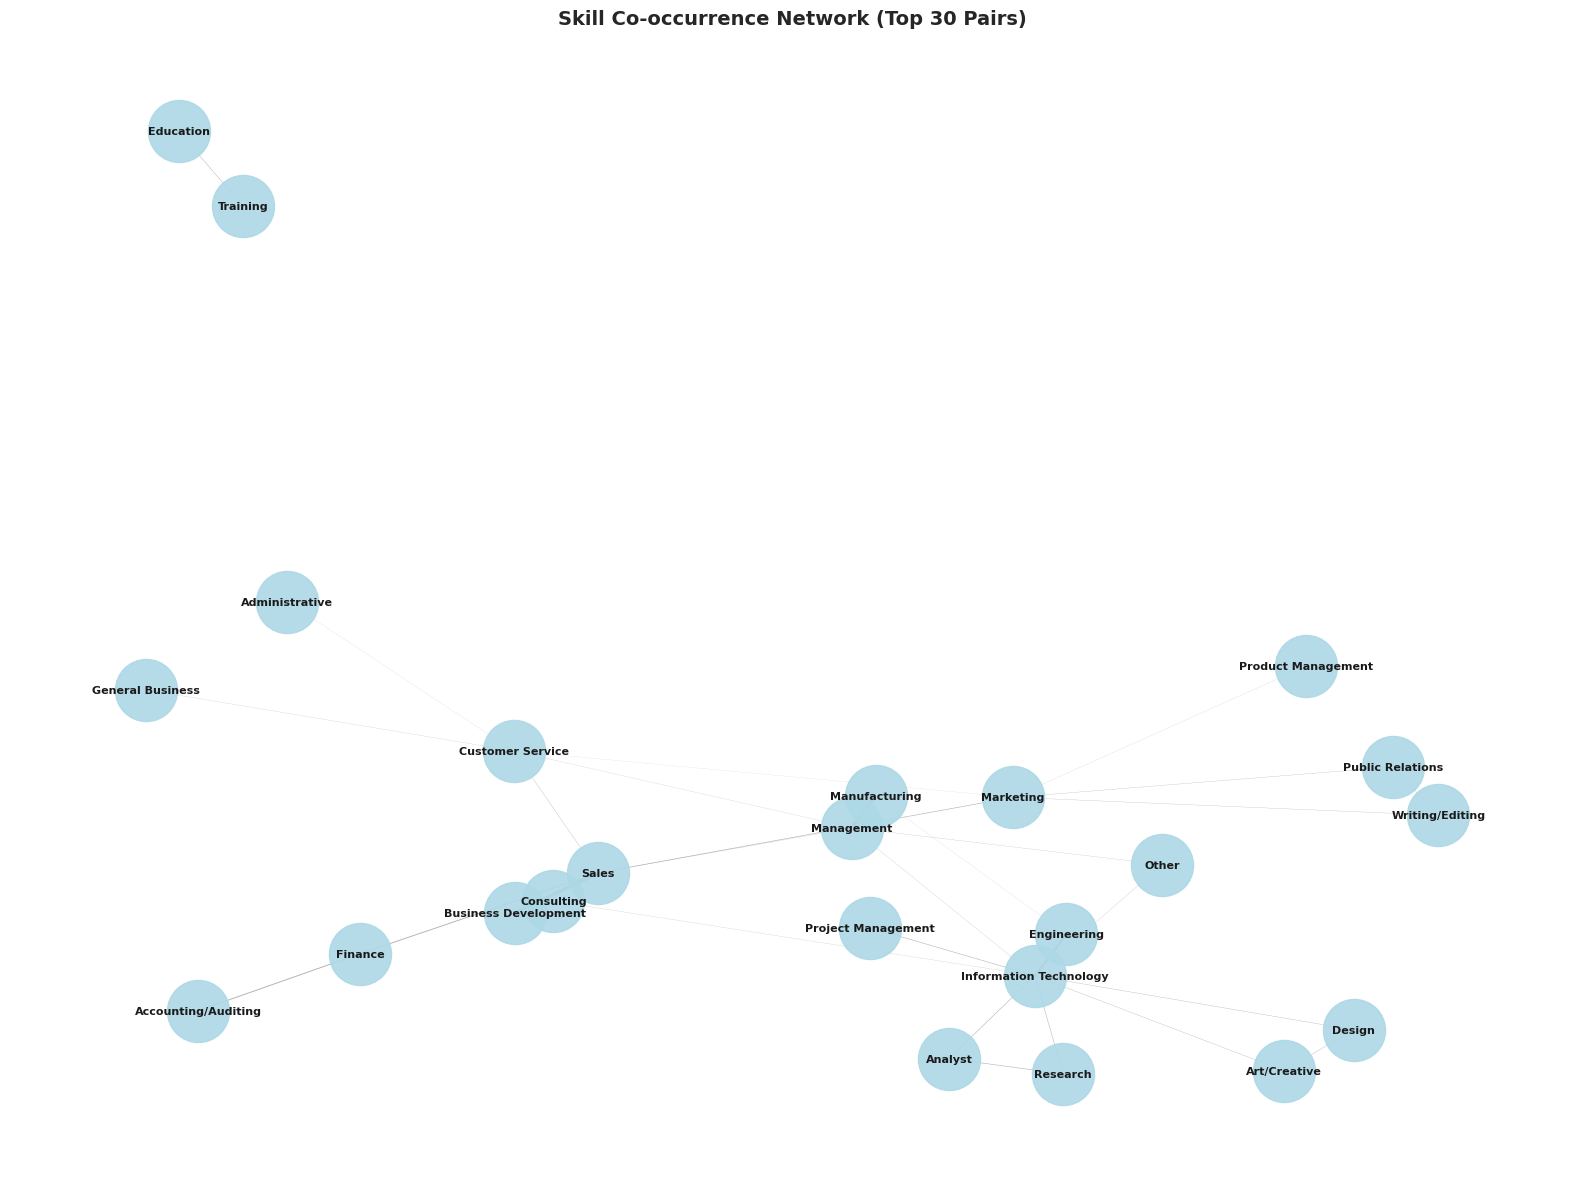

✓ Saved: 07_skill_network_graph.png

CREATING: SKILL PAIR FREQUENCY HEATMAP


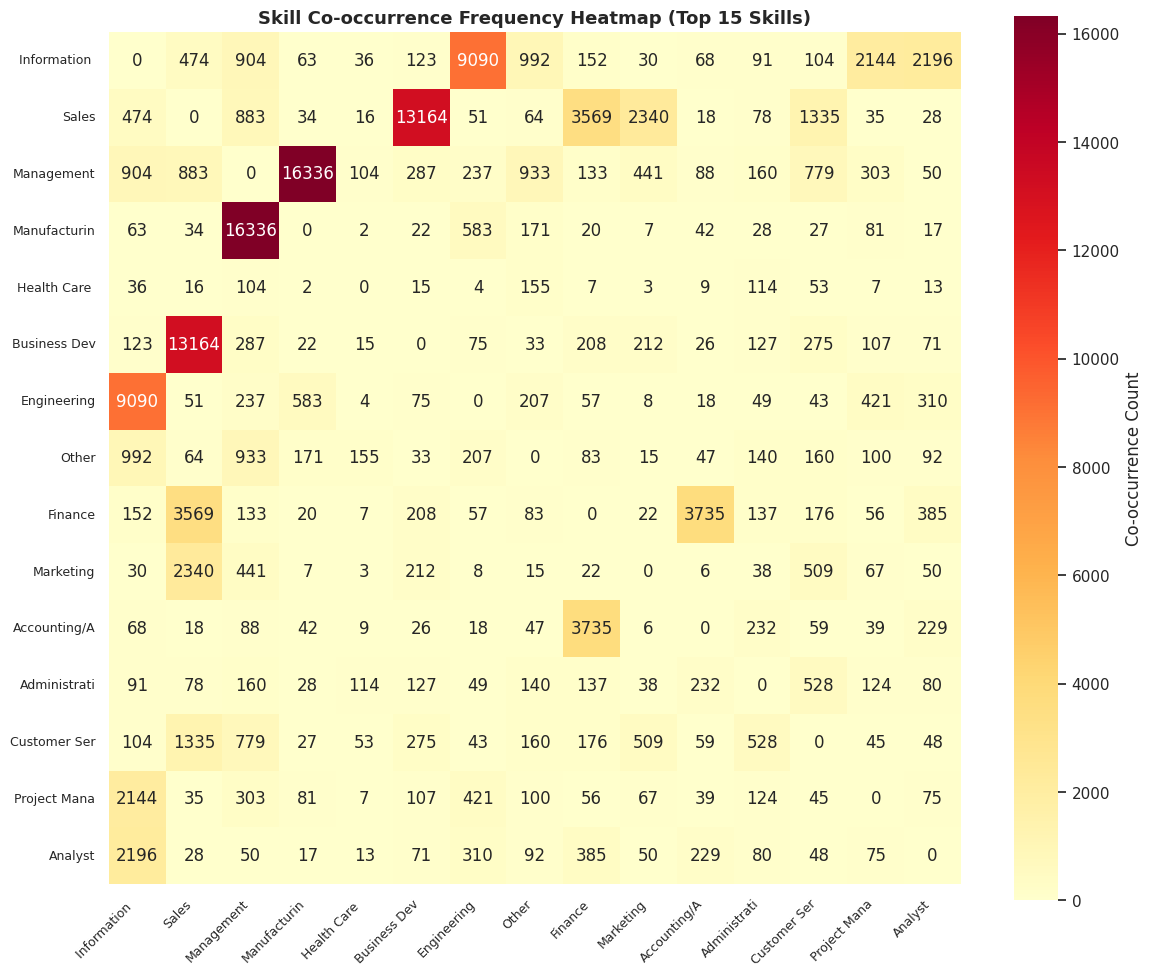

✓ Saved: 08_skill_cooccurrence_heatmap.png

CREATING: SKILL OUTCOME HEATMAPS


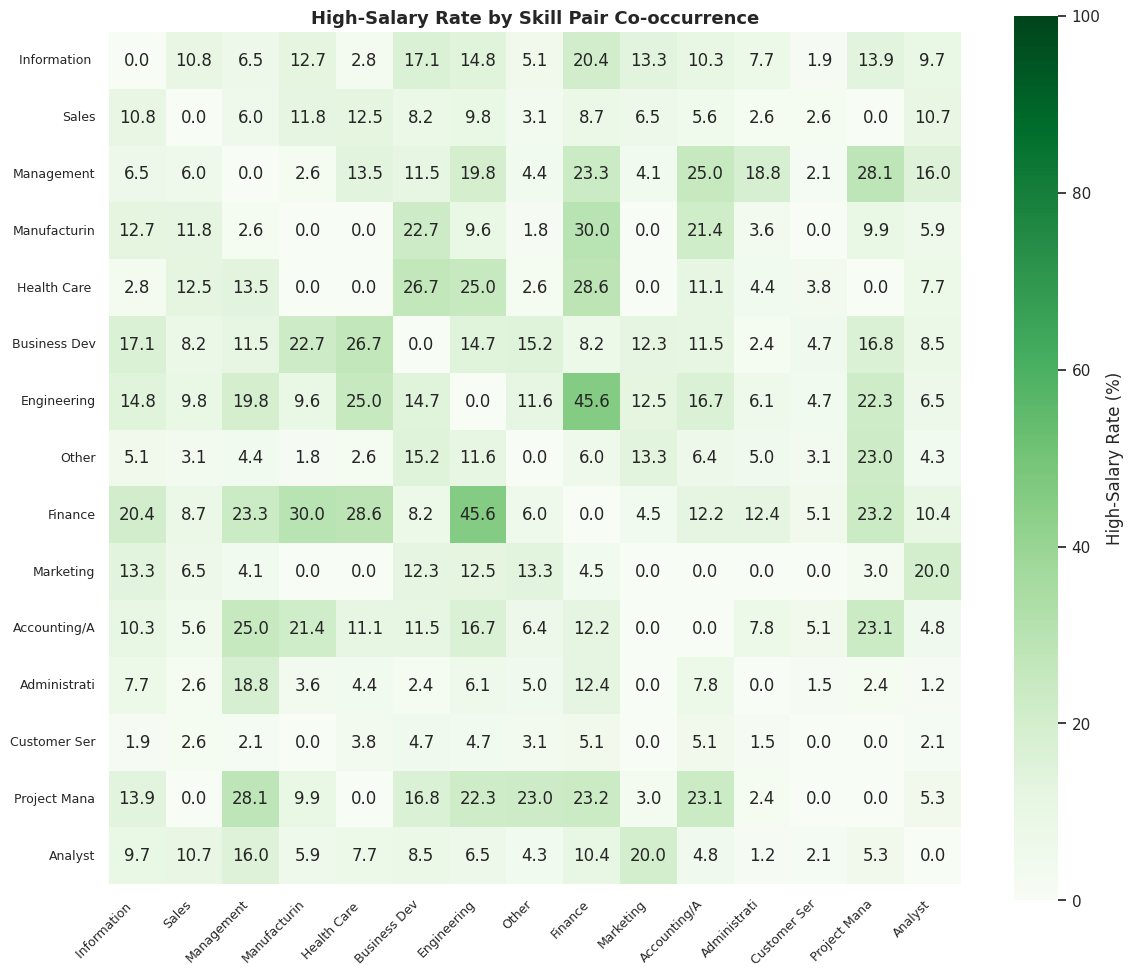

✓ Saved: 09_skill_pairs_high_salary_heatmap.png


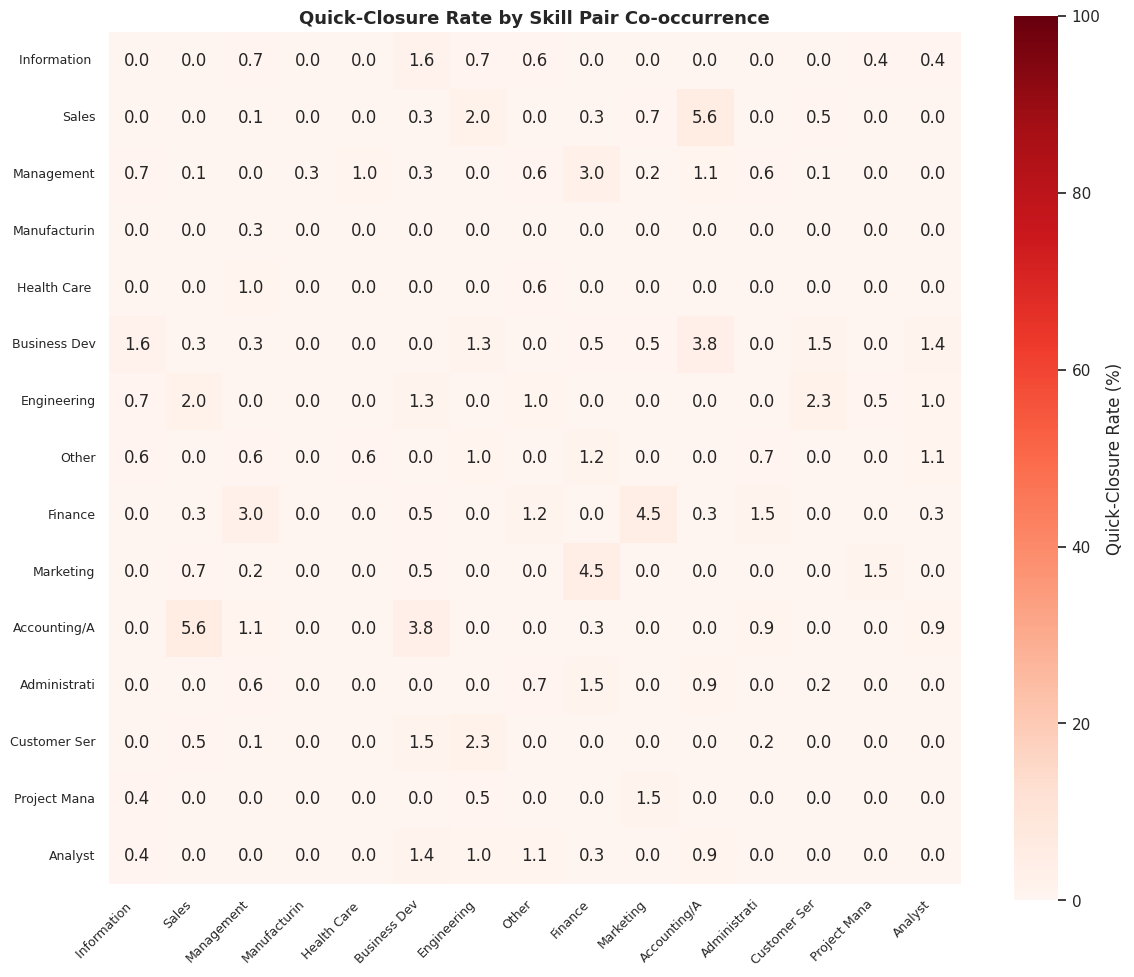

✓ Saved: 10_skill_pairs_quick_closure_heatmap.png

CREATING: SALARY vs CLOSURE SCATTER PLOT


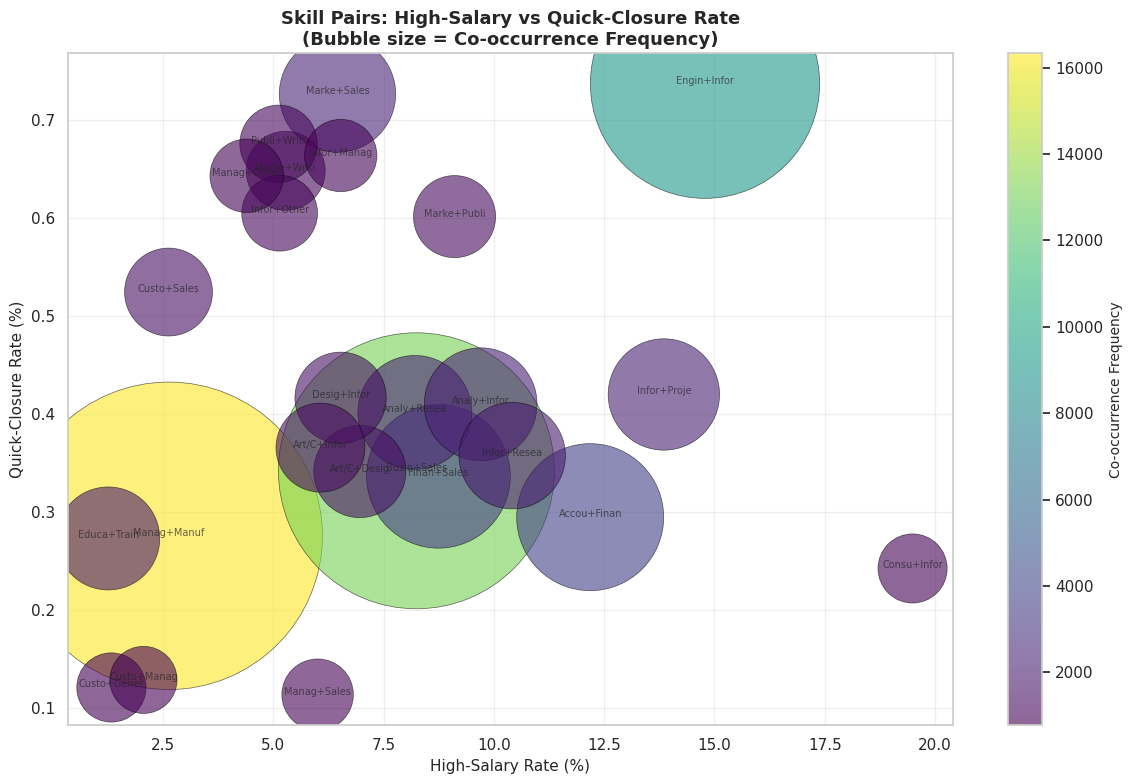

✓ Saved: 11_salary_vs_closure_scatter.png

CREATING: SALARY DISTRIBUTION BY SKILL COUNT


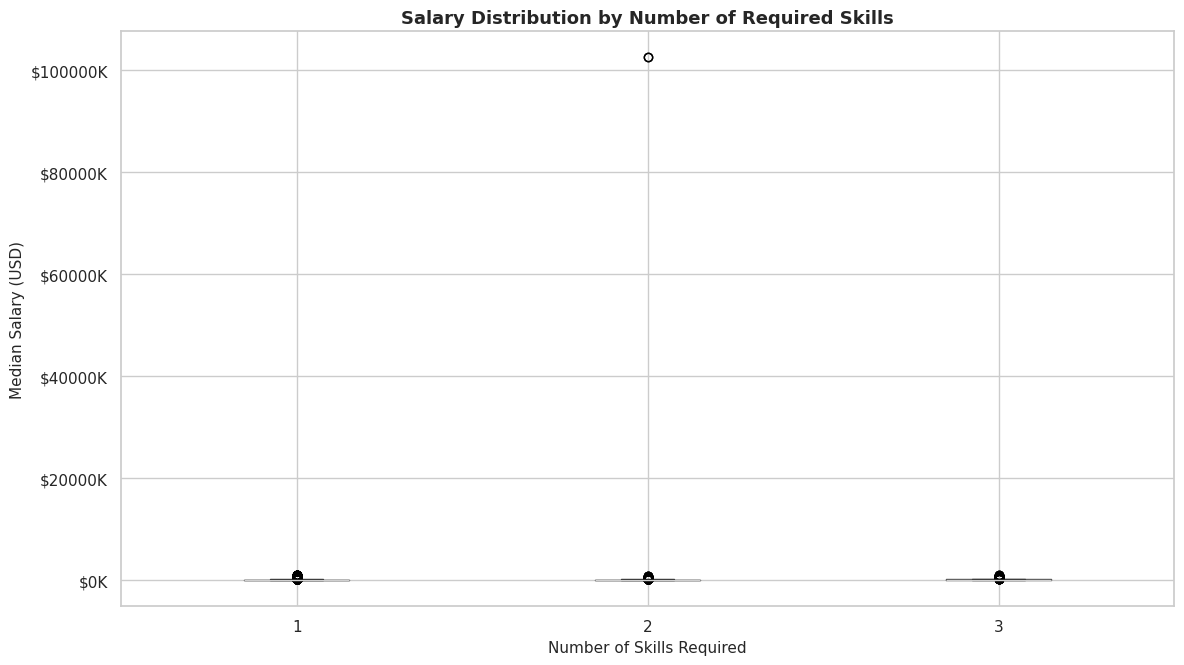

✓ Saved: 12_salary_by_skill_count_boxplot.png

CREATING: CUMULATIVE ANALYSIS

Cumulative Analysis by Skill Count:
            Mean_Salary  Median_Salary  Total_Count  Unique_Jobs
num_skills                                                      
1              61871.14        37900.0        17501        17501
2              77711.17        66500.0        34356        17178
3              79286.36        75000.0        16692         5564


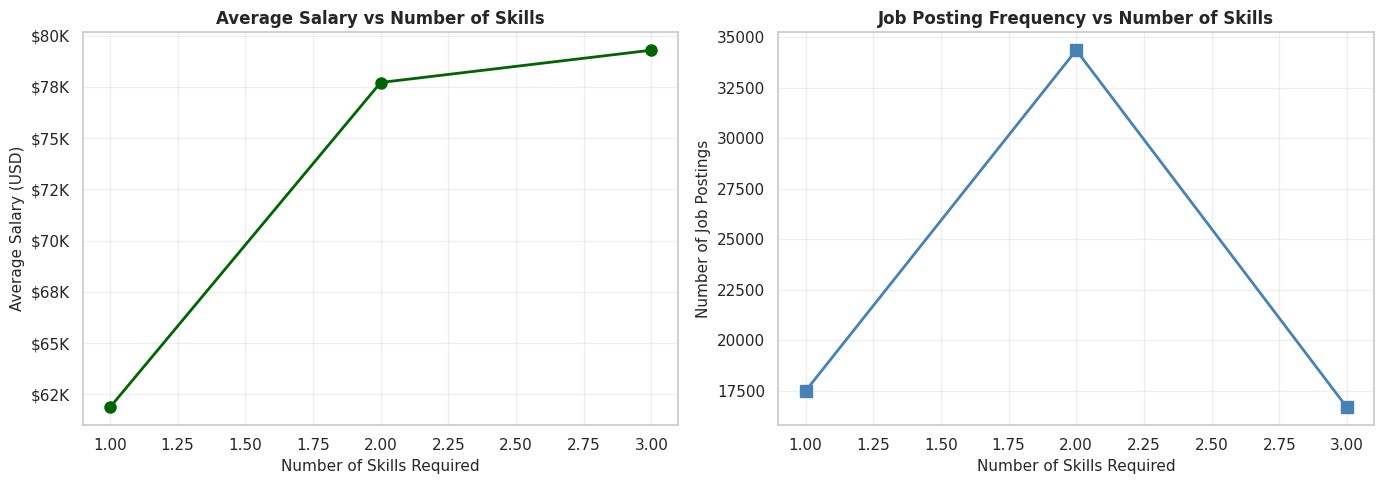

✓ Saved: 13_cumulative_skill_count_analysis.png

ADVANCED VISUALIZATIONS COMPLETE!

Generated Files:
  1. 07_skill_network_graph.png
  2. 08_skill_cooccurrence_heatmap.png
  3. 09_skill_pairs_high_salary_heatmap.png
  4. 10_skill_pairs_quick_closure_heatmap.png
  5. 11_salary_vs_closure_scatter.png
  6. 12_salary_by_skill_count_boxplot.png
  7. 13_cumulative_skill_count_analysis.png


In [24]:
"""
================================================================================
ADVANCED VISUALIZATIONS - NETWORK & CORRELATION ANALYSIS
================================================================================
"""
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("LOADING & PREPARING DATA")
print("="*80)


# Data Cleaning
time_cols = ['original_listed_time', 'expiry', 'closed_time', 'listed_time']
for col in time_cols:
    df_posting[col] = pd.to_datetime(df_posting[col], unit='ms', errors='coerce')

df_posting['company_id'] = df_posting['company_id'].astype('Int64')
df_posting['remote_allowed'] = df_posting['remote_allowed'].fillna(0).astype('Int64')

for col in ['job_description', 'formatted_experience_level', 'skills_desc', 'posting_domain', 'application_url']:
    df_posting[col] = df_posting[col].fillna('Unknown')

df_salaries['med_salary_est'] = df_salaries['med_salary'].fillna(
    (df_salaries['min_salary'] + df_salaries['max_salary']) / 2
)

# Merge data
df_job_skills_merged = df_job_skills.merge(df_skills, on='skill_id', how='left')
df_analysis = df_job_skills_merged.merge(
    df_posting[['job_posting_id', 'title', 'views', 'applies', 'original_listed_time',
                'expiry', 'closed_time', 'formatted_experience_level']],
    on='job_posting_id', how='left'
)
df_analysis = df_analysis.merge(
    df_salaries[['job_posting_id', 'med_salary_est', 'pay_period']],
    on='job_posting_id', how='left'
)

# Create target variables
salary_threshold = df_analysis['med_salary_est'].quantile(0.75)
df_analysis['high_salary'] = (df_analysis['med_salary_est'] >= salary_threshold).astype(int)

df_with_closure = df_analysis[df_analysis['closed_time'].notna()].copy()
df_with_closure['listing_duration'] = (
    (df_with_closure['closed_time'] - df_with_closure['original_listed_time']).dt.days
)
closure_threshold = df_with_closure['listing_duration'].quantile(0.25)
df_with_closure['quick_closure'] = (df_with_closure['listing_duration'] <= closure_threshold).astype(int)

print("✓ Data loaded and cleaned")

# ================================================================================
# VISUALIZATION 1: SKILL CO-OCCURRENCE NETWORK GRAPH
# ================================================================================
print("\n" + "="*80)
print("CREATING: SKILL CO-OCCURRENCE NETWORK GRAPH")
print("="*80)

# Prepare network data
job_skills_dict = df_analysis.groupby('job_posting_id')['skill_name'].apply(list).to_dict()
skill_pairs = Counter()

for job_id, skills in job_skills_dict.items():
    if len(skills) >= 2:
        pairs = combinations(sorted(set(skills)), 2)
        for pair in pairs:
            skill_pairs[pair] += 1

# Create network from top 20 pairs
top_pairs = skill_pairs.most_common(30)
G = nx.Graph()

# Add edges with weights
for (skill1, skill2), count in top_pairs:
    G.add_edge(skill1, skill2, weight=count)

# Create visualization
fig, ax = plt.subplots(figsize=(16, 12))

# Use spring layout for better positioning
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw network
nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                       node_size=2000, ax=ax, alpha=0.9)

# Draw edges with varying thickness based on weight
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights)
edge_widths = [3 * (w / max_weight) for w in weights]

nx.draw_networkx_edges(G, pos, width=edge_widths, ax=ax, alpha=0.6, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Skill Co-occurrence Network (Top 30 Pairs)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 07_skill_network_graph.png")

# ================================================================================
# VISUALIZATION 2: HEATMAP - SKILL PAIR FREQUENCY
# ================================================================================
print("\n" + "="*80)
print("CREATING: SKILL PAIR FREQUENCY HEATMAP")
print("="*80)

# Get top 15 skills
top_skills = df_analysis['skill_name'].value_counts().head(15).index.tolist()

# Create co-occurrence matrix
cooccurrence_matrix = np.zeros((len(top_skills), len(top_skills)))

for job_id, skills in job_skills_dict.items():
    skills_in_top = [s for s in skills if s in top_skills]
    for i, skill1 in enumerate(top_skills):
        for j, skill2 in enumerate(top_skills):
            if i < j and skill1 in skills_in_top and skill2 in skills_in_top:
                cooccurrence_matrix[i][j] += 1
                cooccurrence_matrix[j][i] += 1

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooccurrence_matrix,
            xticklabels=[s[:12] for s in top_skills],
            yticklabels=[s[:12] for s in top_skills],
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Co-occurrence Count'},
            ax=ax,
            square=True)
ax.set_title('Skill Co-occurrence Frequency Heatmap (Top 15 Skills)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 08_skill_cooccurrence_heatmap.png")

# ================================================================================
# VISUALIZATION 3: HEATMAP - SKILL PAIRS vs HIGH SALARY & QUICK CLOSURE
# ================================================================================
print("\n" + "="*80)
print("CREATING: SKILL OUTCOME HEATMAPS")
print("="*80)

# Create matrices for high_salary and quick_closure rates
high_salary_matrix = np.zeros((len(top_skills), len(top_skills)))
quick_closure_matrix = np.zeros((len(top_skills), len(top_skills)))

salary_map = dict(zip(df_analysis[df_analysis['med_salary_est'].notna()]['job_posting_id'],
                     df_analysis[df_analysis['med_salary_est'].notna()]['high_salary']))
closure_map = dict(zip(df_with_closure['job_posting_id'], df_with_closure['quick_closure']))

for job_id, skills in job_skills_dict.items():
    skills_in_top = [s for s in skills if s in top_skills]
    if len(skills_in_top) >= 2:
        for i, skill1 in enumerate(top_skills):
            for j, skill2 in enumerate(top_skills):
                if i < j and skill1 in skills_in_top and skill2 in skills_in_top:
                    if job_id in salary_map and salary_map[job_id] == 1:
                        high_salary_matrix[i][j] += 1
                        high_salary_matrix[j][i] += 1
                    if job_id in closure_map and closure_map[job_id] == 1:
                        quick_closure_matrix[i][j] += 1
                        quick_closure_matrix[j][i] += 1

# Normalize by total co-occurrence
with np.errstate(divide='ignore', invalid='ignore'):
    high_salary_rate = high_salary_matrix / cooccurrence_matrix
    quick_closure_rate = quick_closure_matrix / cooccurrence_matrix
    high_salary_rate[~np.isfinite(high_salary_rate)] = 0
    quick_closure_rate[~np.isfinite(quick_closure_rate)] = 0

# Plot high salary rates
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(high_salary_rate * 100,
            xticklabels=[s[:12] for s in top_skills],
            yticklabels=[s[:12] for s in top_skills],
            annot=True,
            fmt='.1f',
            cmap='Greens',
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'High-Salary Rate (%)'},
            ax=ax,
            square=True)
ax.set_title('High-Salary Rate by Skill Pair Co-occurrence',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 09_skill_pairs_high_salary_heatmap.png")

# Plot quick closure rates
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(quick_closure_rate * 100,
            xticklabels=[s[:12] for s in top_skills],
            yticklabels=[s[:12] for s in top_skills],
            annot=True,
            fmt='.1f',
            cmap='Reds',
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'Quick-Closure Rate (%)'},
            ax=ax,
            square=True)
ax.set_title('Quick-Closure Rate by Skill Pair Co-occurrence',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 10_skill_pairs_quick_closure_heatmap.png")

# ================================================================================
# VISUALIZATION 4: SCATTER PLOT - SALARY vs CLOSURE FOR SKILL PAIRS
# ================================================================================
print("\n" + "="*80)
print("CREATING: SALARY vs CLOSURE SCATTER PLOT")
print("="*80)

scatter_data = []
for (skill1, skill2), count in top_pairs[:25]:
    # High salary rate
    high_sal_count = sum(1 for job_id, skills in job_skills_dict.items()
                        if skill1 in skills and skill2 in skills
                        and job_id in salary_map and salary_map[job_id] == 1)
    total = count
    high_sal_rate = (high_sal_count / total * 100) if total > 0 else 0

    # Quick closure rate
    quick_close_count = sum(1 for job_id, skills in job_skills_dict.items()
                           if skill1 in skills and skill2 in skills
                           and job_id in closure_map and closure_map[job_id] == 1)
    quick_close_rate = (quick_close_count / total * 100) if total > 0 else 0

    scatter_data.append({
        'pair': f"{skill1}\n{skill2}",
        'high_salary_rate': high_sal_rate,
        'quick_closure_rate': quick_close_rate,
        'count': count,
        'skill1': skill1,
        'skill2': skill2
    })

scatter_df = pd.DataFrame(scatter_data)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(scatter_df['high_salary_rate'],
                    scatter_df['quick_closure_rate'],
                    s=scatter_df['count']*3,
                    alpha=0.6,
                    c=scatter_df['count'],
                    cmap='viridis',
                    edgecolors='black',
                    linewidth=0.5)

# Add labels for points
for idx, row in scatter_df.iterrows():
    ax.annotate(f"{row['skill1'][:5]}+{row['skill2'][:5]}",
               (row['high_salary_rate'], row['quick_closure_rate']),
               fontsize=7, alpha=0.7, ha='center')

ax.set_xlabel('High-Salary Rate (%)', fontsize=11)
ax.set_ylabel('Quick-Closure Rate (%)', fontsize=11)
ax.set_title('Skill Pairs: High-Salary vs Quick-Closure Rate\n(Bubble size = Co-occurrence Frequency)',
            fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Co-occurrence Frequency', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 11_salary_vs_closure_scatter.png")

# ================================================================================
# VISUALIZATION 5: BOX PLOT - SALARY DISTRIBUTION BY SKILL COMBINATIONS
# ================================================================================
print("\n" + "="*80)
print("CREATING: SALARY DISTRIBUTION BY SKILL COUNT")
print("="*80)

# Add skill count to analysis
df_analysis_copy = df_analysis.copy()
skill_counts_per_job = df_analysis.groupby('job_posting_id')['skill_name'].nunique()
df_analysis_copy['num_skills'] = df_analysis_copy['job_posting_id'].map(skill_counts_per_job)

# Filter for salary data and reasonable skill counts
salary_skill_count = df_analysis_copy[
    (df_analysis_copy['med_salary_est'].notna()) &
    (df_analysis_copy['num_skills'] <= 10)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))
salary_skill_count.boxplot(column='med_salary_est', by='num_skills', ax=ax)
ax.set_xlabel('Number of Skills Required', fontsize=11)
ax.set_ylabel('Median Salary (USD)', fontsize=11)
ax.set_title('Salary Distribution by Number of Required Skills', fontsize=13, fontweight='bold')
ax.get_figure().suptitle('')  # Remove the automatic title
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 12_salary_by_skill_count_boxplot.png")

# ================================================================================
# VISUALIZATION 6: CUMULATIVE ANALYSIS - SKILL COMBINATIONS IMPACT
# ================================================================================
print("\n" + "="*80)
print("CREATING: CUMULATIVE ANALYSIS")
print("="*80)

# Group by skill count and analyze
cumulative_analysis = salary_skill_count.groupby('num_skills').agg({
    'med_salary_est': ['mean', 'median', 'count'],
    'job_posting_id': 'nunique'
}).round(2)

cumulative_analysis.columns = ['Mean_Salary', 'Median_Salary', 'Total_Count', 'Unique_Jobs']
cumulative_analysis = cumulative_analysis[cumulative_analysis['Total_Count'] >= 10]

print(f"\nCumulative Analysis by Skill Count:")
print(cumulative_analysis)

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean salary by skill count
cumulative_analysis['Mean_Salary'].plot(ax=ax1, marker='o', linewidth=2, color='darkgreen', markersize=8)
ax1.set_xlabel('Number of Skills Required', fontsize=11)
ax1.set_ylabel('Average Salary (USD)', fontsize=11)
ax1.set_title('Average Salary vs Number of Skills', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax1.grid(True, alpha=0.3)

# Plot 2: Job count by skill count
cumulative_analysis['Total_Count'].plot(ax=ax2, marker='s', linewidth=2, color='steelblue', markersize=8)
ax2.set_xlabel('Number of Skills Required', fontsize=11)
ax2.set_ylabel('Number of Job Postings', fontsize=11)
ax2.set_title('Job Posting Frequency vs Number of Skills', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
print("✓ Saved: 13_cumulative_skill_count_analysis.png")

print("\n" + "="*80)
print("ADVANCED VISUALIZATIONS COMPLETE!")
print("="*80)
print("\nGenerated Files:")
print("  1. 07_skill_network_graph.png")
print("  2. 08_skill_cooccurrence_heatmap.png")
print("  3. 09_skill_pairs_high_salary_heatmap.png")
print("  4. 10_skill_pairs_quick_closure_heatmap.png")
print("  5. 11_salary_vs_closure_scatter.png")
print("  6. 12_salary_by_skill_count_boxplot.png")
print("  7. 13_cumulative_skill_count_analysis.png")

### EDA(4): Bagaimana variasi kompensasi (gaji) dipengaruhi oleh kombinasi: industri, skill teknis vs. non-teknis, ukuran perusahaan, dan lokasi ?

#### exploratory

In [25]:
# ==========================================
# A. PENGGABUNGAN DATA (MERGE)
# ==========================================
# 1. Mulai dari tabel gaji, filter hanya yang memiliki estimasi gaji (med_salary_est)
df_salary_clean = df_salaries.dropna(subset=['med_salary_est']).copy()

# 2. Gabungkan dengan df_posting untuk mendapatkan lokasi dan company_id
df_eda = df_salary_clean.merge(df_posting[['job_posting_id', 'company_id', 'location']],
                               on='job_posting_id', how='inner')

# 3. Gabungkan dengan df_companies untuk mendapatkan company_size
df_eda = df_eda.merge(df_companies[['company_id', 'company_size', 'state']],
                      on='company_id', how='left')

# 4. Gabungkan dengan industri
df_eda = df_eda.merge(df_job_industries[['job_posting_id', 'industry_id']], on='job_posting_id', how='left')
df_eda = df_eda.merge(df_industries[['industry_id', 'industry_name']], on='industry_id', how='left')

# 5. Gabungkan dengan skills
df_eda = df_eda.merge(df_job_skills[['job_posting_id', 'skill_id']], on='job_posting_id', how='left')
df_eda = df_eda.merge(df_skills[['skill_id', 'skill_name']], on='skill_id', how='left')

# ==========================================
# B. NORMALISASI GAJI (TAHUNAN)
# ==========================================
# Gaji memiliki pay_period berbeda (Hourly, Monthly, Yearly). Kita standarkan ke Yearly (Tahunan).
def normalize_salary_to_yearly(row):
    salary = row['med_salary_est']
    period = str(row['pay_period']).upper()

    if period == 'HOURLY':
        return salary * 2080  # Asumsi 40 jam/minggu * 52 minggu
    elif period == 'MONTHLY':
        return salary * 12
    else:
        return salary # Asumsi default Yearly

df_eda['yearly_salary_est'] = df_eda.apply(normalize_salary_to_yearly, axis=1)

# ==========================================
# C. KLASIFIKASI SKILL (TEKNIS VS NON-TEKNIS)
# ==========================================
# Karena dataset tidak membedakan ini secara otomatis, kita gunakan keyword matching sederhana.
# Anda bisa menambahkan keyword ini sesuai dengan nilai unik pada df_skills['skill_name'].
tech_keywords = ['IT', 'Engineering', 'Software', 'Data', 'Programming', 'Cloud', 'Network',
                 'Developer', 'Analytics', 'Design', 'ART'] # ART merujuk pada sampel 'contoh DSGN'

def classify_skill(skill_name):
    if pd.isna(skill_name):
        return 'Unknown'
    skill_upper = str(skill_name).upper()
    for kw in tech_keywords:
        if kw.upper() in skill_upper:
            return 'Technical'
    return 'Non-Technical'

df_eda['skill_category'] = df_eda['skill_name'].apply(classify_skill)

print("Data berhasil digabung dan disiapkan untuk analisis kompensasi!")

Data berhasil digabung dan disiapkan untuk analisis kompensasi!


In [26]:
# Hapus duplikasi jika satu job_posting punya banyak skill namun kita hanya ingin melihat level lowongan
# untuk analisis ukuran perusahaan, industri, dan lokasi.
df_jobs_unique = df_eda.drop_duplicates(subset=['job_posting_id'])

print("--- Median Gaji Berdasarkan Ukuran Perusahaan ---")
print(df_jobs_unique.groupby('company_size')['yearly_salary_est'].median().sort_values())

print("\n--- Top 5 Industri dengan Gaji Tertinggi ---")
print(df_jobs_unique.groupby('industry_name')['yearly_salary_est'].median().nlargest(5))

print("\n--- Median Gaji: Technical vs Non-Technical ---")
# Disini kita gunakan df_eda utuh (karena levelnya per skill)
print(df_eda[df_eda['skill_category'] != 'Unknown'].groupby('skill_category')['yearly_salary_est'].median())

--- Median Gaji Berdasarkan Ukuran Perusahaan ---
company_size
7    73840.0
6    74880.0
4    81000.0
5    82160.0
1    85000.0
2    85000.0
3    87500.0
Name: yearly_salary_est, dtype: float64

--- Top 5 Industri dengan Gaji Tertinggi ---
industry_name
Real Estate Agents and Brokers              350000.0
Climate Technology Product Manufacturing    309000.0
Capital Markets                             275000.0
Animation and Post-production               257500.0
Residential Building Construction           200000.0
Name: yearly_salary_est, dtype: float64

--- Median Gaji: Technical vs Non-Technical ---
skill_category
Non-Technical     81408.0
Technical        105000.0
Name: yearly_salary_est, dtype: float64


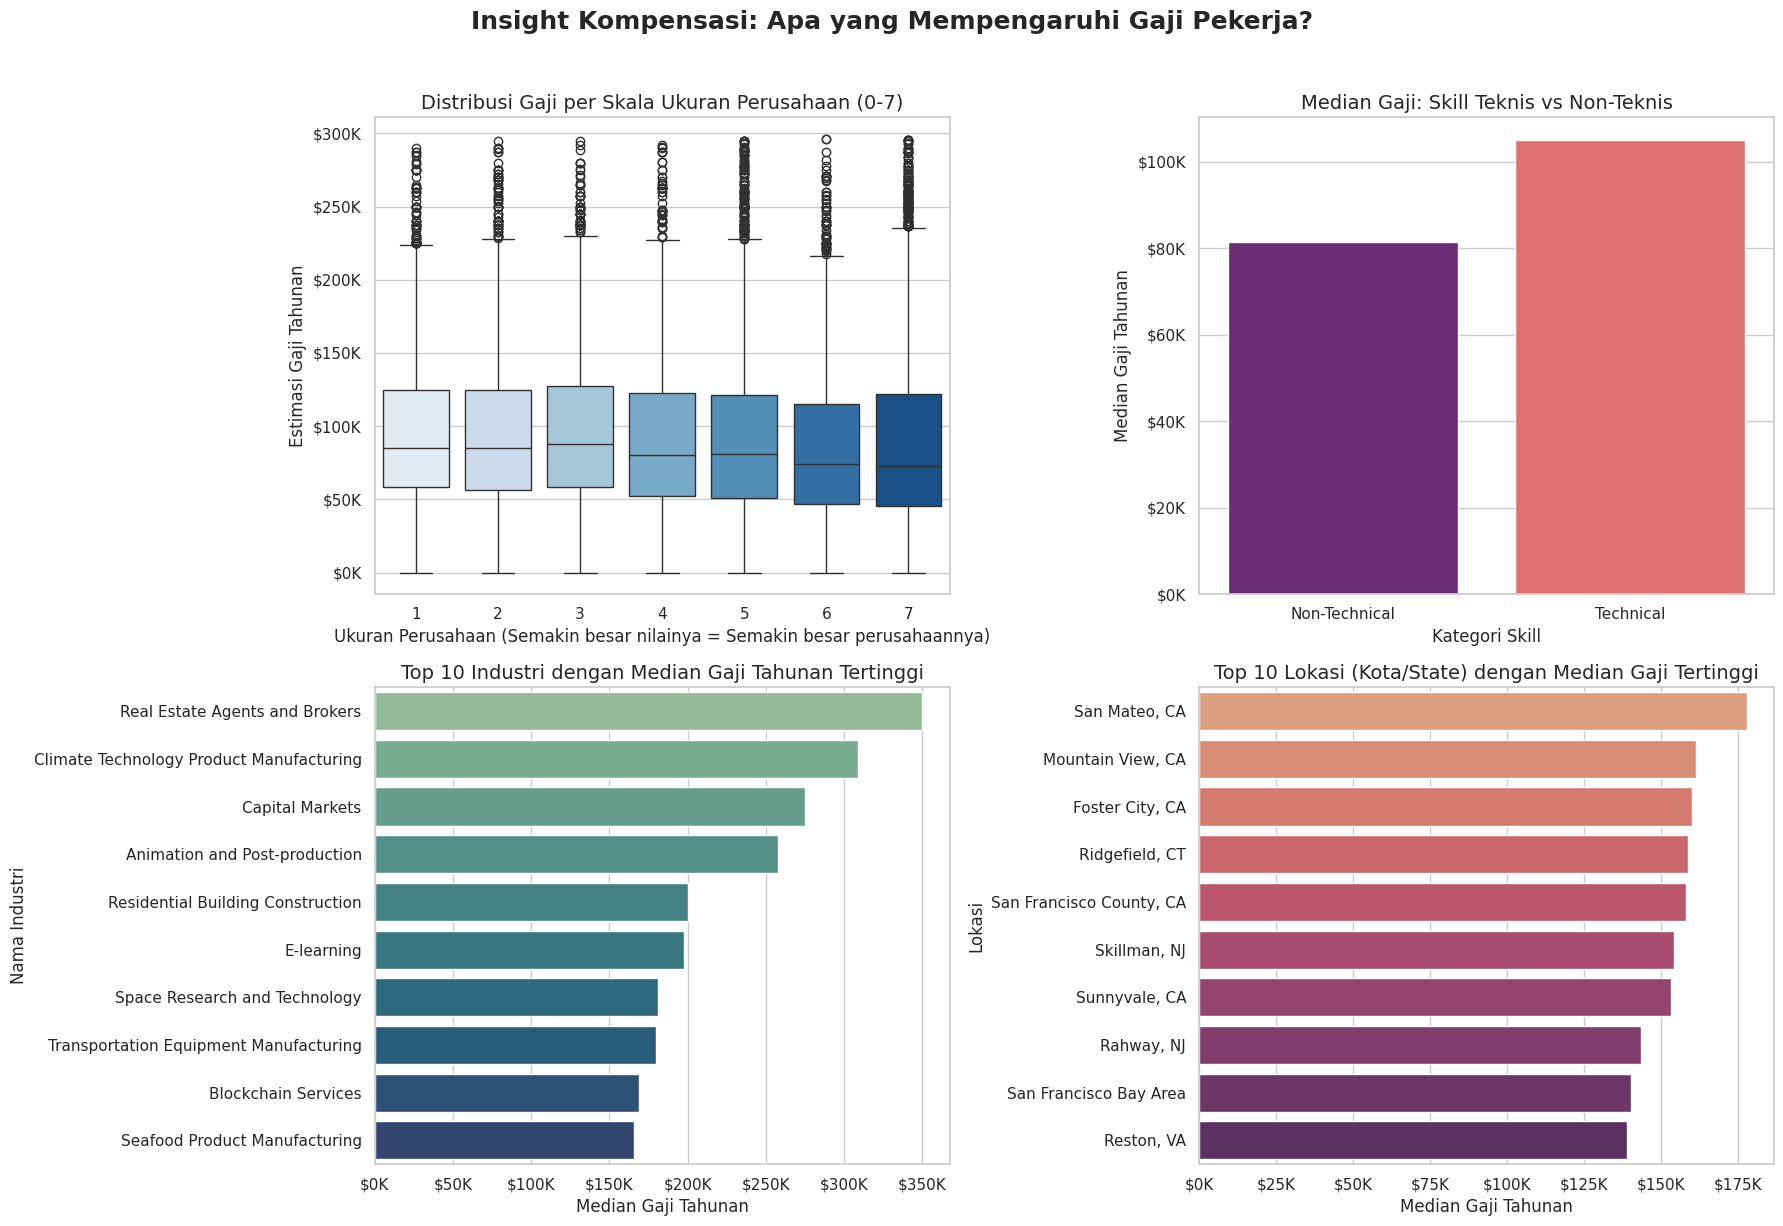

In [27]:
# Set up tema Seaborn
sns.set_theme(style="whitegrid", palette="Set2")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Insight Kompensasi: Apa yang Mempengaruhi Gaji Pekerja?', fontsize=18, y=1.02, fontweight='bold')

# =========================================================
# 1. Variasi Gaji Berdasarkan Ukuran Perusahaan (Boxplot)
# =========================================================
# Kita gunakan batas gaji misal < $300,000 agar outlier ekstrem tidak merusak visualisasi
df_plot_size = df_jobs_unique[(df_jobs_unique['yearly_salary_est'] < 300000) & (df_jobs_unique['company_size'].notna())]

sns.boxplot(data=df_plot_size, x='company_size', y='yearly_salary_est', ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title('Distribusi Gaji per Skala Ukuran Perusahaan (0-7)', fontsize=14)
axes[0, 0].set_xlabel('Ukuran Perusahaan (Semakin besar nilainya = Semakin besar perusahaannya)')
axes[0, 0].set_ylabel('Estimasi Gaji Tahunan')

# =========================================================
# 2. Variasi Gaji: Teknis vs Non-Teknis (Barplot)
# =========================================================
df_plot_skill = df_eda[df_eda['skill_category'] != 'Unknown']
sns.barplot(data=df_plot_skill, x='skill_category', y='yearly_salary_est',
            estimator=np.median, errorbar=None, ax=axes[0, 1], palette="magma")
axes[0, 1].set_title('Median Gaji: Skill Teknis vs Non-Teknis', fontsize=14)
axes[0, 1].set_xlabel('Kategori Skill')
axes[0, 1].set_ylabel('Median Gaji Tahunan')

# =========================================================
# 3. Variasi Gaji Berdasarkan Industri (Horizontal Barplot - Top 10)
# =========================================================
top_industries = df_jobs_unique.groupby('industry_name')['yearly_salary_est'].median().nlargest(10).reset_index()

sns.barplot(data=top_industries, x='yearly_salary_est', y='industry_name', ax=axes[1, 0], palette="crest")
axes[1, 0].set_title('Top 10 Industri dengan Median Gaji Tahunan Tertinggi', fontsize=14)
axes[1, 0].set_xlabel('Median Gaji Tahunan')
axes[1, 0].set_ylabel('Nama Industri')

# =========================================================
# 4. Variasi Gaji Berdasarkan Lokasi (Horizontal Barplot - Top 10)
# =========================================================
# Ambil top 10 lokasi dengan lowongan yang cukup banyak untuk menghindari bias dari 1 lowongan anomali
location_counts = df_jobs_unique['location'].value_counts()
valid_locations = location_counts[location_counts > 10].index

df_valid_loc = df_jobs_unique[df_jobs_unique['location'].isin(valid_locations)]
top_locations = df_valid_loc.groupby('location')['yearly_salary_est'].median().nlargest(10).reset_index()

sns.barplot(data=top_locations, x='yearly_salary_est', y='location', ax=axes[1, 1], palette="flare")
axes[1, 1].set_title('Top 10 Lokasi (Kota/State) dengan Median Gaji Tertinggi', fontsize=14)
axes[1, 1].set_xlabel('Median Gaji Tahunan')
axes[1, 1].set_ylabel('Lokasi')

# Merapikan label angka pada sumbu X / Y agar mudah dibaca (misal: 100000 -> 100K)
import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')

axes[0,0].yaxis.set_major_formatter(formatter)
axes[0,1].yaxis.set_major_formatter(formatter)
axes[1,0].xaxis.set_major_formatter(formatter)
axes[1,1].xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#### explanatory

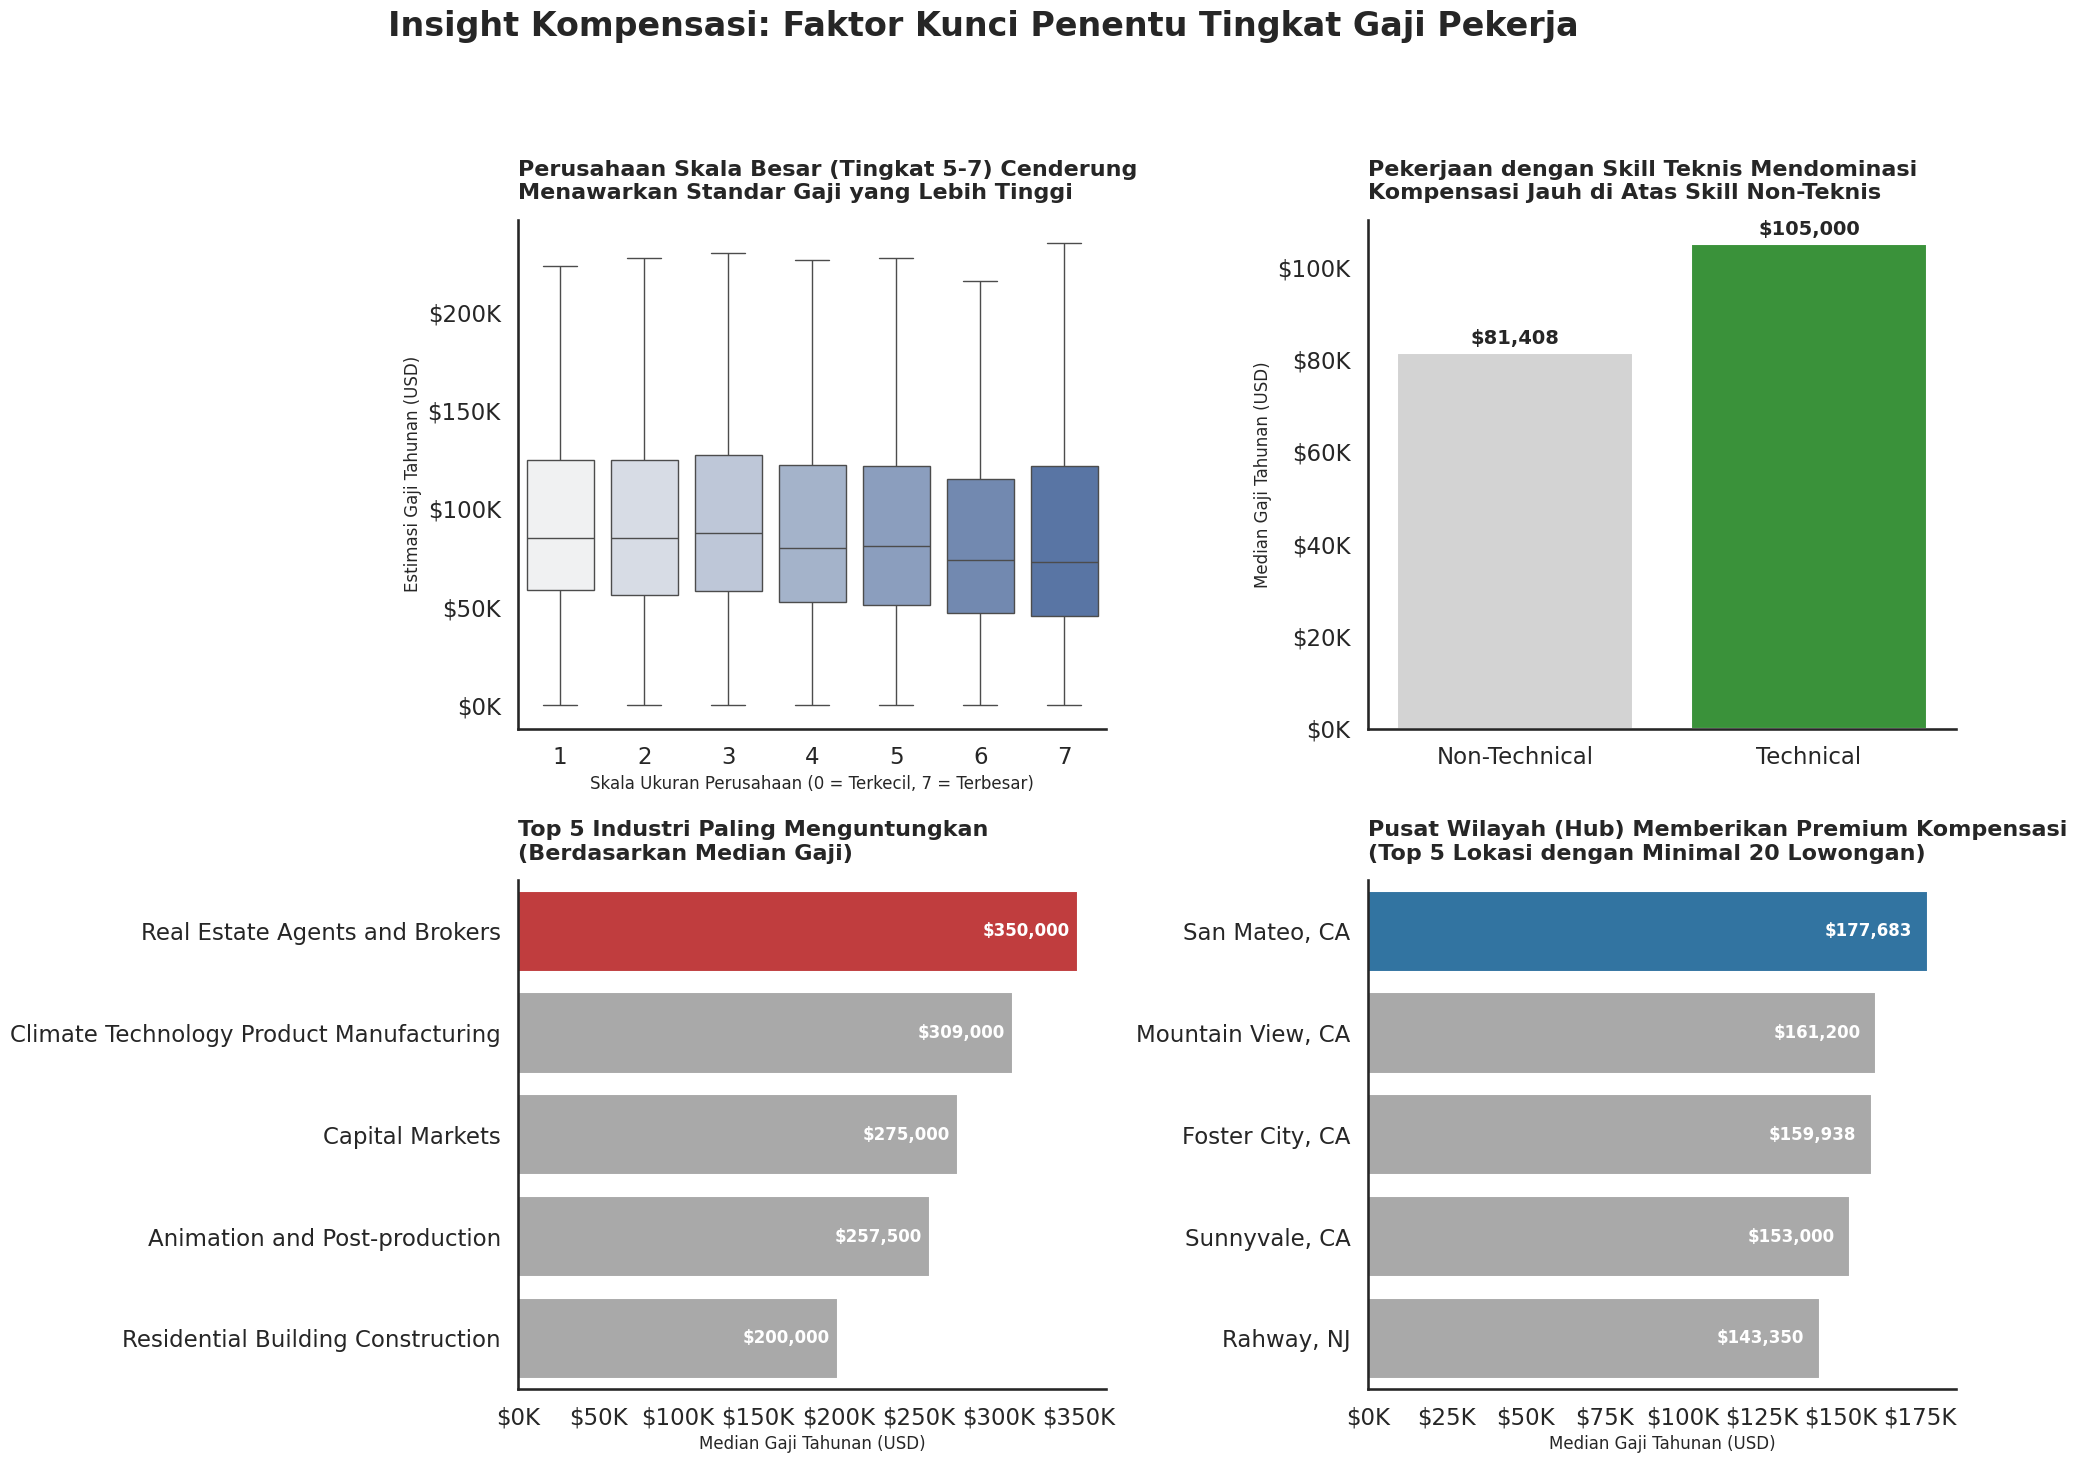

In [28]:
# Mengatur gaya visualisasi yang bersih dan profesional
sns.set_theme(style="white", context="talk")

# Membuat grid layout untuk 4 visualisasi
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Insight Kompensasi: Faktor Kunci Penentu Tingkat Gaji Pekerja',
             fontsize=24, fontweight='bold', y=1.05)

# =====================================================================
# 1. INSIGHT: UKURAN PERUSAHAAN VS GAJI
# =====================================================================
df_size = df_jobs_unique.dropna(subset=['company_size', 'yearly_salary_est'])
# Filter outlier ekstrem agar cerita lebih fokus pada distribusi umum
df_size = df_size[df_size['yearly_salary_est'] < 300000]

sns.boxplot(data=df_size, x='company_size', y='yearly_salary_est',
            ax=axes[0, 0], palette="light:b", showfliers=False)
axes[0, 0].set_title('Perusahaan Skala Besar (Tingkat 5-7) Cenderung\nMenawarkan Standar Gaji yang Lebih Tinggi',
                     fontsize=16, fontweight='bold', pad=15, loc='left')
axes[0, 0].set_xlabel('Skala Ukuran Perusahaan (0 = Terkecil, 7 = Terbesar)', fontsize=12)
axes[0, 0].set_ylabel('Estimasi Gaji Tahunan (USD)', fontsize=12)
sns.despine(ax=axes[0, 0]) # Menghilangkan garis tepi atas dan kanan agar bersih

# =====================================================================
# 2. INSIGHT: SKILL TEKNIS VS NON-TEKNIS
# =====================================================================
df_skill = df_eda[df_eda['skill_category'] != 'Unknown']
skill_median = df_skill.groupby('skill_category')['yearly_salary_est'].median().reset_index()

# Membuat bar chart dengan highlight warna
colors = ['#d3d3d3' if cat == 'Non-Technical' else '#2ca02c' for cat in skill_median['skill_category']]
sns.barplot(data=skill_median, x='skill_category', y='yearly_salary_est',
            ax=axes[0, 1], palette=colors)

axes[0, 1].set_title('Pekerjaan dengan Skill Teknis Mendominasi\nKompensasi Jauh di Atas Skill Non-Teknis',
                     fontsize=16, fontweight='bold', pad=15, loc='left')
axes[0, 1].set_xlabel('', fontsize=12)
axes[0, 1].set_ylabel('Median Gaji Tahunan (USD)', fontsize=12)

# Anotasi angka pada bar
for i, v in enumerate(skill_median['yearly_salary_est']):
    axes[0, 1].text(i, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=14)
sns.despine(ax=axes[0, 1])

# =====================================================================
# 3. INSIGHT: TOP INDUSTRI
# =====================================================================
top_industries = df_jobs_unique.groupby('industry_name')['yearly_salary_est'].median().nlargest(5).reset_index()

# Highlight warna merah bata untuk industri tertinggi, abu-abu untuk yang lain
ind_colors = ['#d62728' if i == 0 else '#a9a9a9' for i in range(len(top_industries))]
sns.barplot(data=top_industries, x='yearly_salary_est', y='industry_name',
            ax=axes[1, 0], palette=ind_colors)

axes[1, 0].set_title('Top 5 Industri Paling Menguntungkan\n(Berdasarkan Median Gaji)',
                     fontsize=16, fontweight='bold', pad=15, loc='left')
axes[1, 0].set_xlabel('Median Gaji Tahunan (USD)', fontsize=12)
axes[1, 0].set_ylabel('')

# Anotasi di dalam bar
for i, v in enumerate(top_industries['yearly_salary_est']):
    axes[1, 0].text(v - 5000, i, f'${v:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=12)
sns.despine(ax=axes[1, 0])

# =====================================================================
# 4. INSIGHT: LOKASI DENGAN GAJI TERTINGGI
# =====================================================================
# Filter lokasi yang kemunculannya cukup representatif (misal > 20 lowongan)
loc_counts = df_jobs_unique['location'].value_counts()
valid_locs = loc_counts[loc_counts > 20].index
df_valid_loc = df_jobs_unique[df_jobs_unique['location'].isin(valid_locs)]

top_locs = df_valid_loc.groupby('location')['yearly_salary_est'].median().nlargest(5).reset_index()

loc_colors = ['#1f77b4' if i == 0 else '#a9a9a9' for i in range(len(top_locs))]
sns.barplot(data=top_locs, x='yearly_salary_est', y='location',
            ax=axes[1, 1], palette=loc_colors)

axes[1, 1].set_title('Pusat Wilayah (Hub) Memberikan Premium Kompensasi\n(Top 5 Lokasi dengan Minimal 20 Lowongan)',
                     fontsize=16, fontweight='bold', pad=15, loc='left')
axes[1, 1].set_xlabel('Median Gaji Tahunan (USD)', fontsize=12)
axes[1, 1].set_ylabel('')

for i, v in enumerate(top_locs['yearly_salary_est']):
    axes[1, 1].text(v - 5000, i, f'${v:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=12)
sns.despine(ax=axes[1, 1])

# =====================================================================
# FORMATTING SUMBU Y & X (Ribuan K)
# =====================================================================
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
axes[0,0].yaxis.set_major_formatter(formatter)
axes[0,1].yaxis.set_major_formatter(formatter)
axes[1,0].xaxis.set_major_formatter(formatter)
axes[1,1].xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.subplots_adjust(top=0.90) # Memberi ruang ekstra untuk Super Title
plt.show()